# GPT Solutions step by step

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

base_path = r"../playground-series-s5e11/"

train = pd.read_csv(base_path + "train.csv")
test = pd.read_csv(base_path + "test.csv")

train_org = train.copy()
test_org = test.copy()

print("✅ Train shape:", train.shape)
print("✅ Test shape:", test.shape)

print("\n🔍 Train columns:\n", train.columns.tolist())
print("\n🔍 First few rows of train:")
display(train.head())

print("\n📋 Data types:")
print(train.dtypes)


✅ Train shape: (593994, 13)
✅ Test shape: (254569, 12)

🔍 Train columns:
 ['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_paid_back']

🔍 First few rows of train:


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0



📋 Data types:
id                        int64
annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
interest_rate           float64
gender                   object
marital_status           object
education_level          object
employment_status        object
loan_purpose             object
grade_subgrade           object
loan_paid_back          float64
dtype: object


In [13]:
# Missing values summary
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("🔍 Missing values per column:\n", missing)

# Duplicates
print("\n🧱 Duplicate rows:", train.duplicated().sum())

# Unique counts for categorical variables
cat_cols = train.select_dtypes(include="object").columns
print("\n🧩 Unique values in categorical columns:")
for col in cat_cols:
    print(f"{col}: {train[col].nunique()} unique values")


🔍 Missing values per column:
 Series([], dtype: int64)

🧱 Duplicate rows: 0

🧩 Unique values in categorical columns:
gender: 3 unique values
marital_status: 4 unique values
education_level: 5 unique values
employment_status: 5 unique values
loan_purpose: 8 unique values
grade_subgrade: 30 unique values


<Axes: xlabel='loan_paid_back', ylabel='count'>

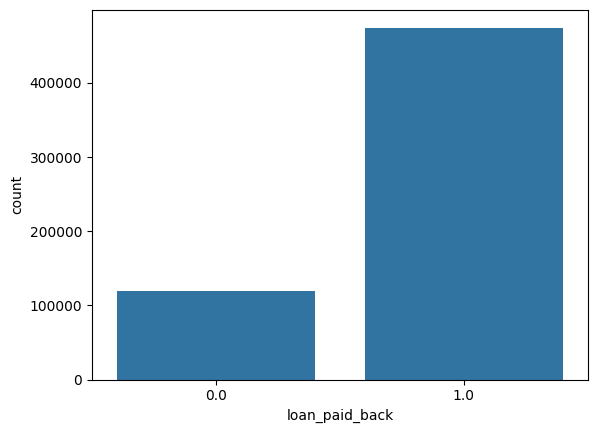

In [14]:
import seaborn as sns
sns.countplot(x='loan_paid_back', data=train)

In [15]:
train.describe().T


,count,mean,std,min,25%,50%,75%,max
id,593994.0,296996.500000,171471.442236,0.000,148498.250,296996.500,445494.750,593993.000
annual_income,593994.0,48212.202976,26711.942078,6002.430,27934.400,46557.680,60981.320,393381.740
debt_to_income_ratio,593994.0,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,680.916009,55.424956,395.000,646.000,682.000,719.000,849.000
loan_amount,593994.0,15020.297629,6926.530568,500.090,10279.620,15000.220,18858.580,48959.950
interest_rate,593994.0,12.356345,2.008959,3.200,10.990,12.370,13.680,20.990
loan_paid_back,593994.0,0.798820,0.400883,0.000,1.000,1.000,1.000,1.000


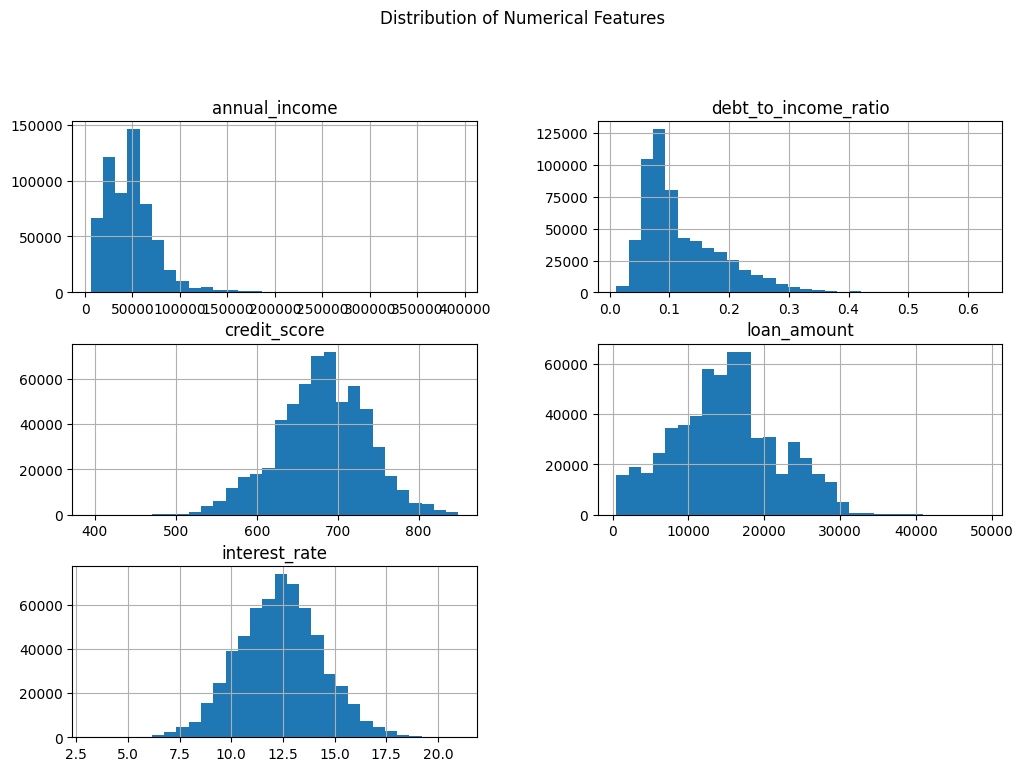

In [16]:
numeric_cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
train[numeric_cols].hist(bins=30, figsize=(12,8))
plt.suptitle("Distribution of Numerical Features", y=1.02)
plt.show()

In [17]:
cat_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
for c in cat_cols:
    print(f"\n{c} value counts:")
    print(train[c].value_counts(normalize=True))



gender value counts:
gender
Female    0.515451
Male      0.478273
Other     0.006276
Name: proportion, dtype: float64

marital_status value counts:
marital_status
Single      0.486273
Married     0.466737
Divorced    0.035879
Widowed     0.011111
Name: proportion, dtype: float64

education_level value counts:
education_level
Bachelor's     0.470722
High School    0.309081
Master's       0.156731
Other          0.044911
PhD            0.018556
Name: proportion, dtype: float64

employment_status value counts:
employment_status
Employed         0.758669
Unemployed       0.105195
Self-employed    0.088351
Retired          0.027699
Student          0.020086
Name: proportion, dtype: float64

loan_purpose value counts:
loan_purpose
Debt consolidation    0.546630
Other                 0.107533
Car                   0.097826
Home                  0.074273
Education             0.061686
Business              0.059433
Medical               0.038394
Vacation              0.014224
Name: proportion

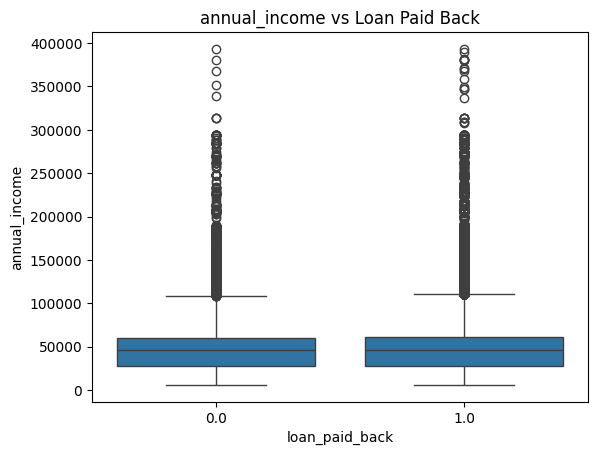

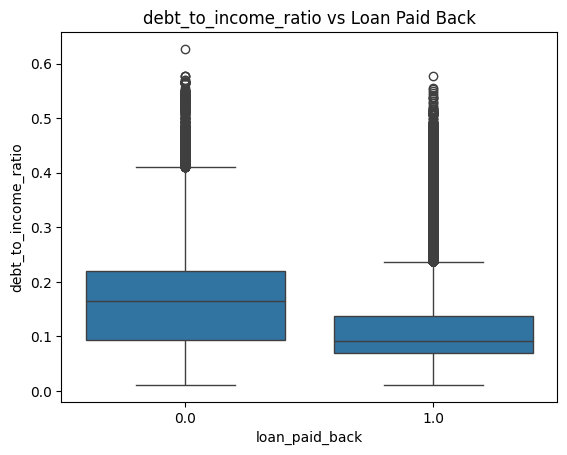

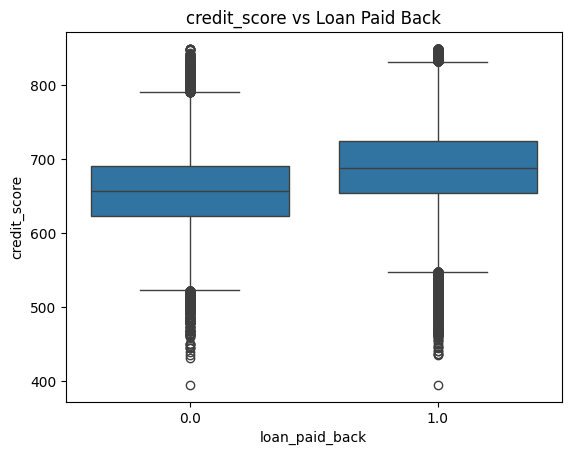

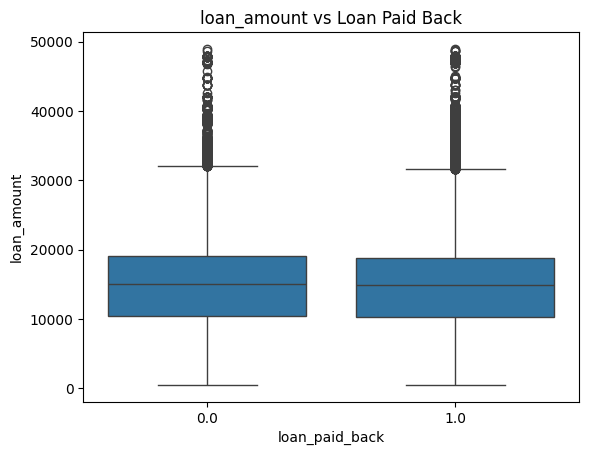

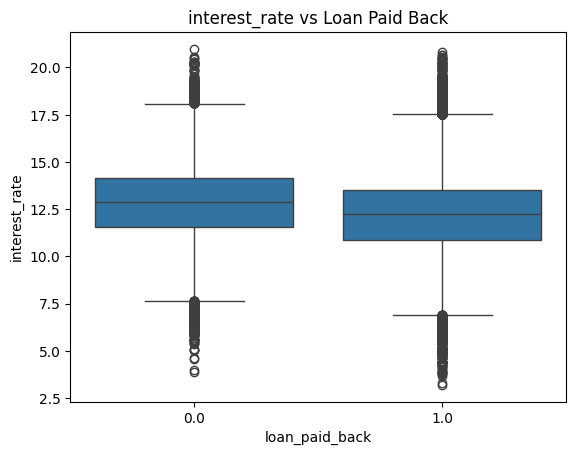

In [18]:
# Step 5.1: Bivariate Analysis (Target Relationships) Numeric
for c in numeric_cols:
    sns.boxplot(x='loan_paid_back', y=c, data=train)
    plt.title(f"{c} vs Loan Paid Back")
    plt.show()

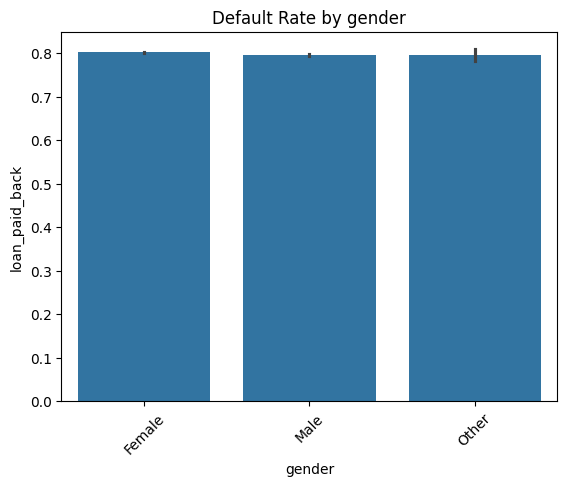

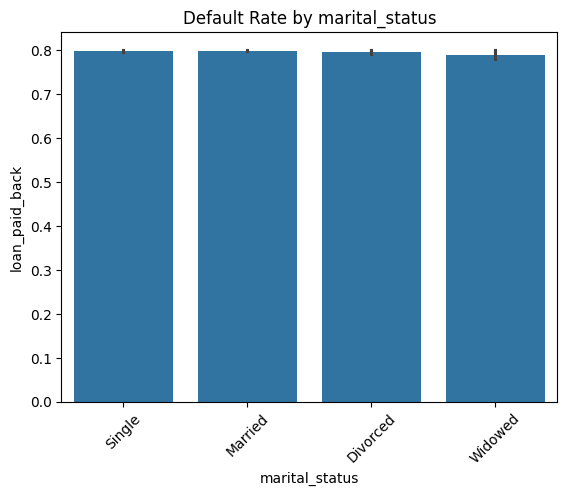

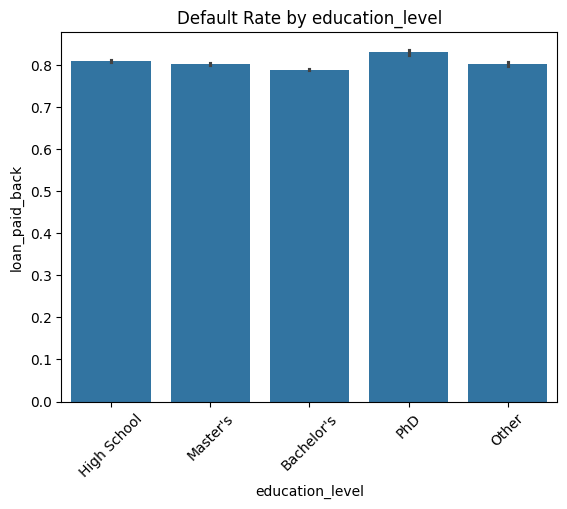

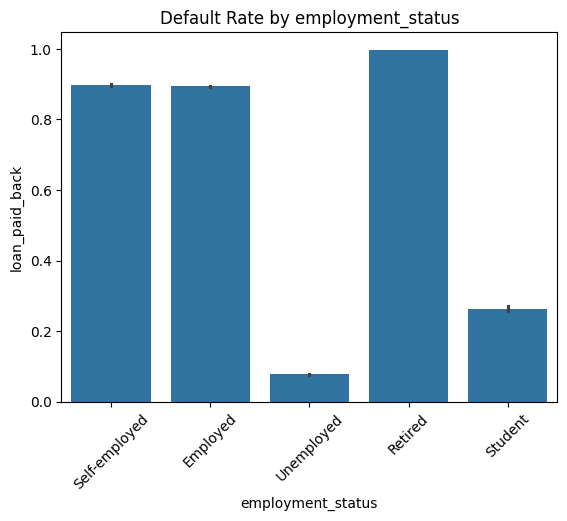

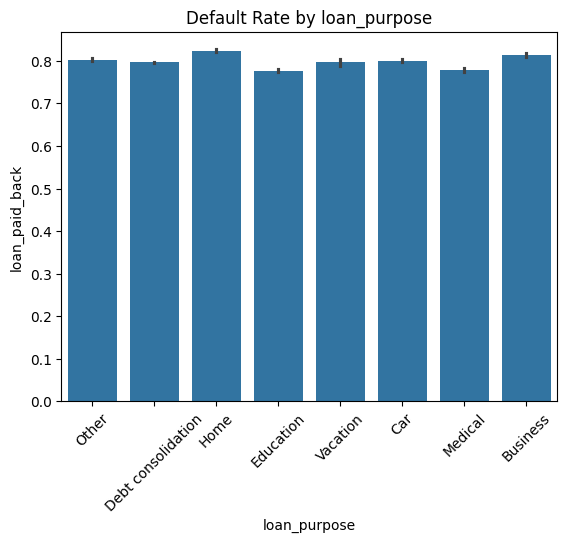

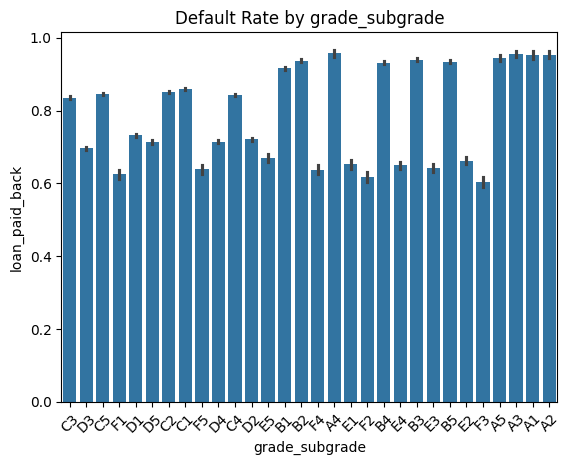

In [19]:
import numpy as np
# Step 5.2: Bivariate Analysis (Target Relationships) Categorical
for c in cat_cols:
    sns.barplot(x=c, y='loan_paid_back', data=train, estimator=np.mean)
    plt.title(f"Default Rate by {c}")
    plt.xticks(rotation=45)
    plt.show()

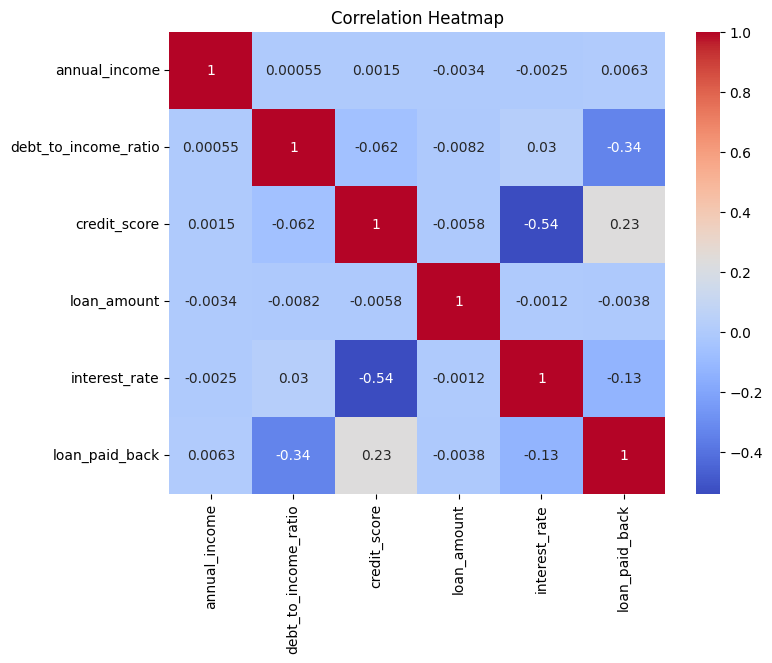

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(train[numeric_cols + ['loan_paid_back']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


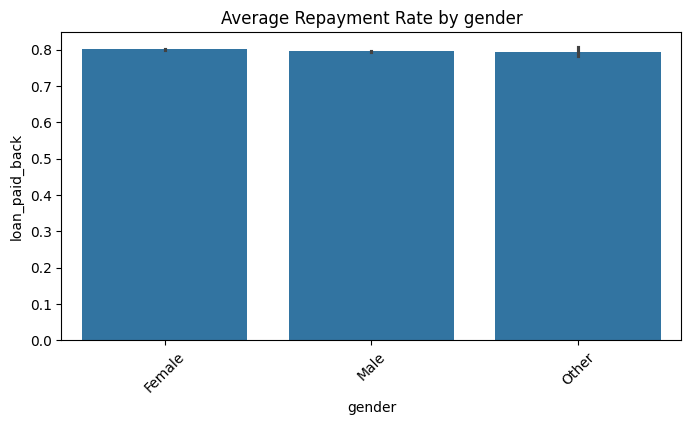

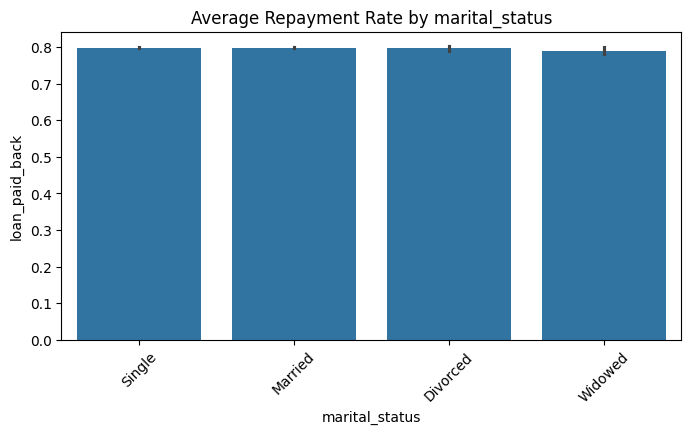

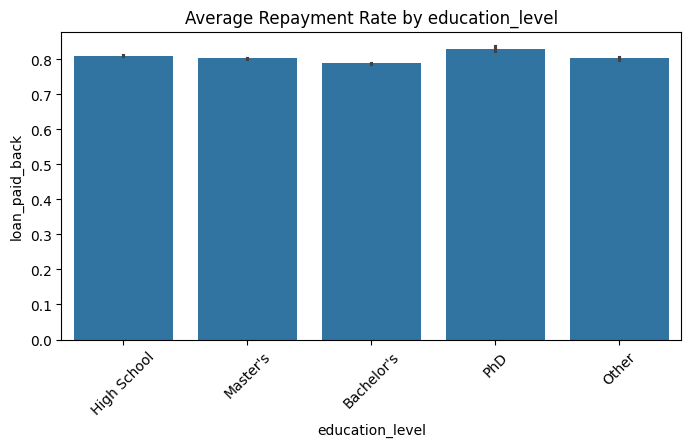

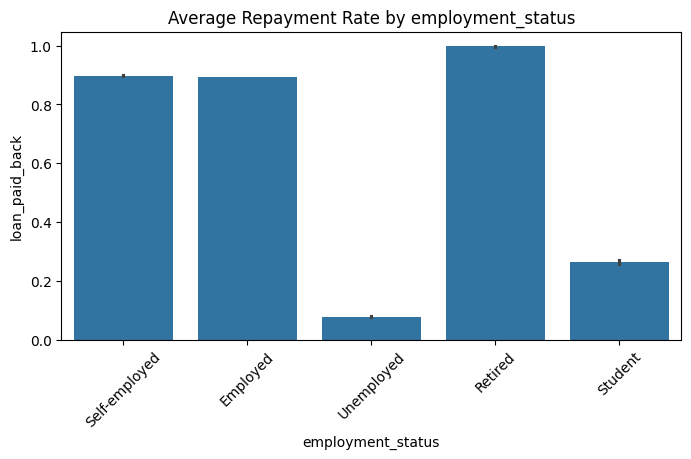

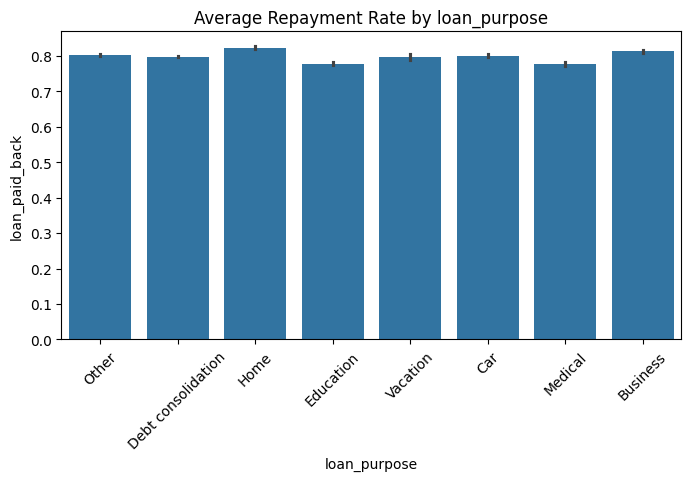

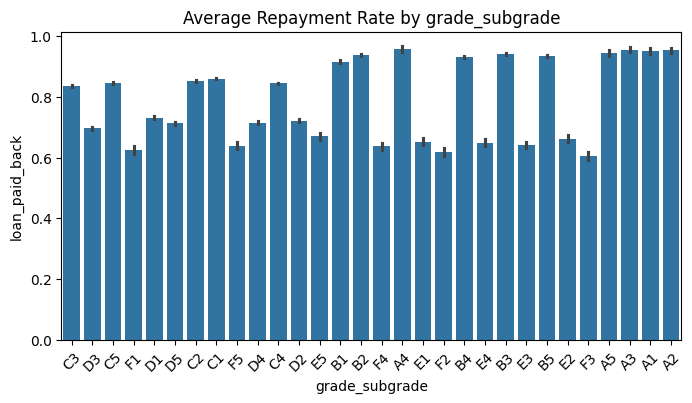

In [21]:
cat_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
for c in cat_cols:
    plt.figure(figsize=(8,4))
    sns.barplot(x=c, y='loan_paid_back', data=train, estimator=np.mean)
    plt.title(f"Average Repayment Rate by {c}")
    plt.xticks(rotation=45)
    plt.show()


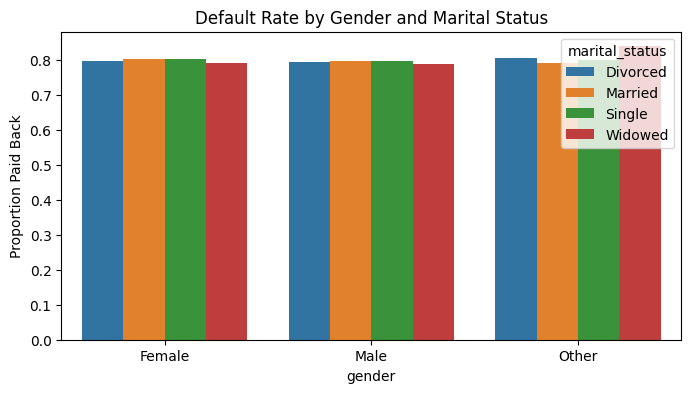

In [22]:
# Marriage and Gender combination
df = train.copy()
df['gender_marital'] = df['gender'] + '_' + df['marital_status']
df['education_employment'] = df['education_level'] + '_' + df['employment_status']

combo = df.groupby(['gender', 'marital_status'])['loan_paid_back'].mean().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=combo, x='gender', y='loan_paid_back', hue='marital_status')
plt.title("Default Rate by Gender and Marital Status")
plt.ylabel("Proportion Paid Back")
plt.show()

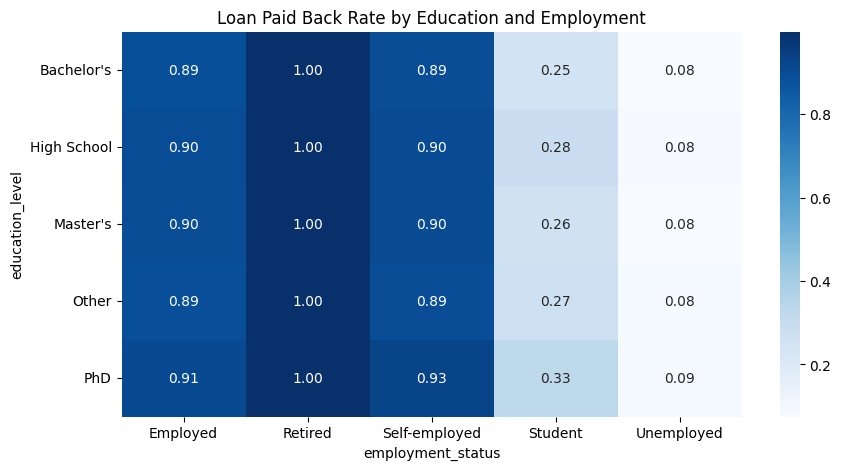

In [23]:
# Education and employment status
combo2 = df.groupby(['education_level', 'employment_status'])['loan_paid_back'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.heatmap(combo2.pivot(index = 'education_level', columns = 'employment_status', values = 'loan_paid_back'),
            annot=True, cmap='Blues', fmt='.2f')
plt.title("Loan Paid Back Rate by Education and Employment")
plt.show()

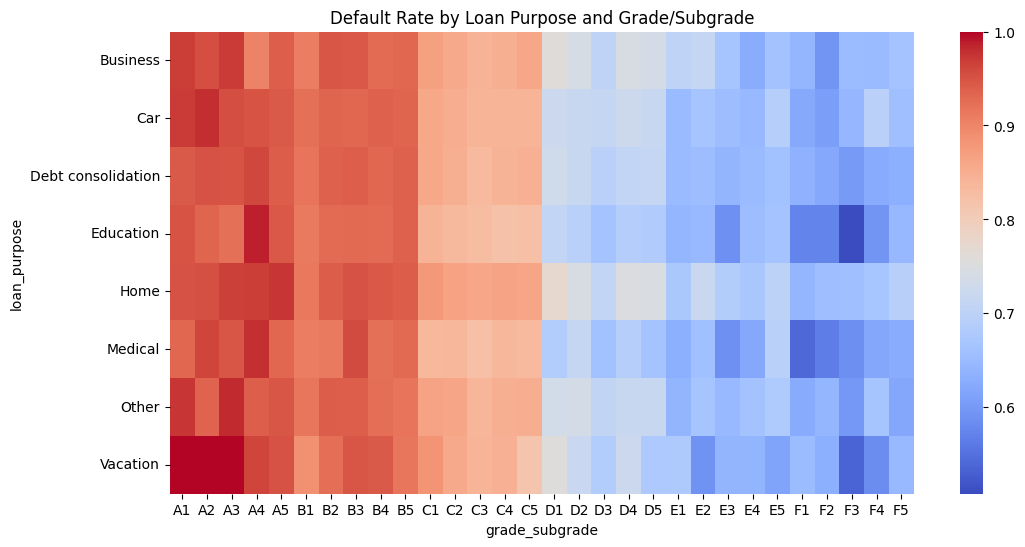

In [24]:
combo3 = df.groupby(['loan_purpose', 'grade_subgrade'])['loan_paid_back'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.heatmap(combo3.pivot(index = 'loan_purpose', columns = 'grade_subgrade', values = 'loan_paid_back'),
            annot=False, cmap='coolwarm')
plt.title("Default Rate by Loan Purpose and Grade/Subgrade")
plt.show()


In [25]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df['gender_marital'], df['loan_paid_back'])
chi2, p, dof, ex = chi2_contingency(ct)
print(f"For gender_marital: Chi2 = {chi2:.2f}, p = {p:.4f}")

ct = pd.crosstab(df['grade_subgrade'], df['loan_paid_back'])
chi2, p, dof, ex = chi2_contingency(ct)
print(f"For grade_subgrade: Chi2 = {chi2:.2f}, p = {p:.4f}")

ct = pd.crosstab(df['education_employment'], df['loan_paid_back'])
chi2, p, dof, ex = chi2_contingency(ct)
print(f"For education_employment: Chi2 = {chi2:.2f}, p = {p:.4f}")


For gender_marital: Chi2 = 38.92, p = 0.0001
For grade_subgrade: Chi2 = 30871.16, p = 0.0000
For education_employment: Chi2 = 256356.18, p = 0.0000


🔢 4️⃣ Chi-square Significance Overview
| Feature Combination  | χ² Value  | p-value | Strength         | Interpretation                                  |
| -------------------- | --------- | ------- | ---------------- | ----------------------------------------------- |
| gender_marital       | 38.92     | 0.0001  | 🔹 Weak–Moderate | Statistically significant but effect size small |
| grade_subgrade       | 30871.16  | <0.0001 | 🔸 Strong        | Extremely predictive of loan repayment          |
| education_employment | 256356.18 | <0.0001 | 🔥 Very Strong   | Strong dependence — major driver of repayment   |


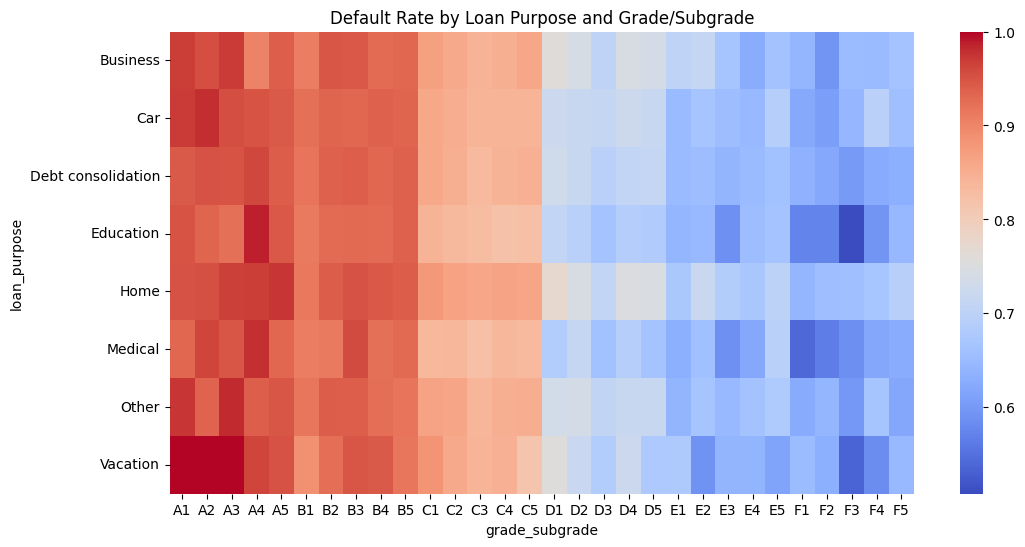

In [26]:
df["grade_purpose"] = df["grade_subgrade"] + '_' + df["loan_purpose"]
combo4 = df.groupby(['loan_purpose', 'grade_subgrade'])['loan_paid_back'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.heatmap(combo3.pivot(index = 'loan_purpose', columns = 'grade_subgrade', values = 'loan_paid_back'),
            annot=False, cmap='coolwarm')
plt.title("Default Rate by Loan Purpose and Grade/Subgrade")
plt.show()


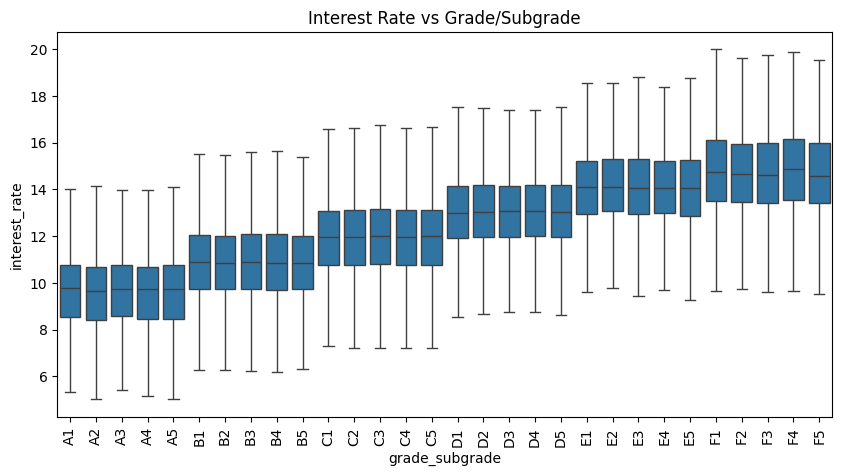

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(data=train.sort_values(by="grade_subgrade"), x='grade_subgrade', y='interest_rate', showfliers=False)
plt.xticks(rotation=90)
plt.title("Interest Rate vs Grade/Subgrade")
plt.show()

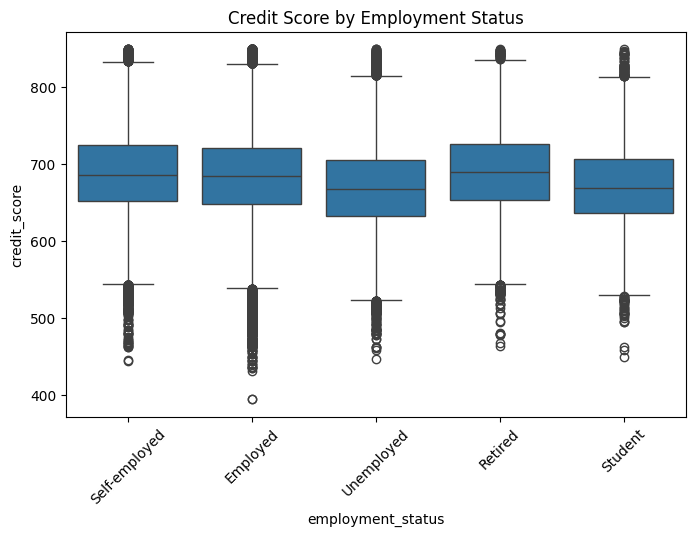

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='employment_status', y='credit_score')
plt.title("Credit Score by Employment Status")
plt.xticks(rotation=45)
plt.show()


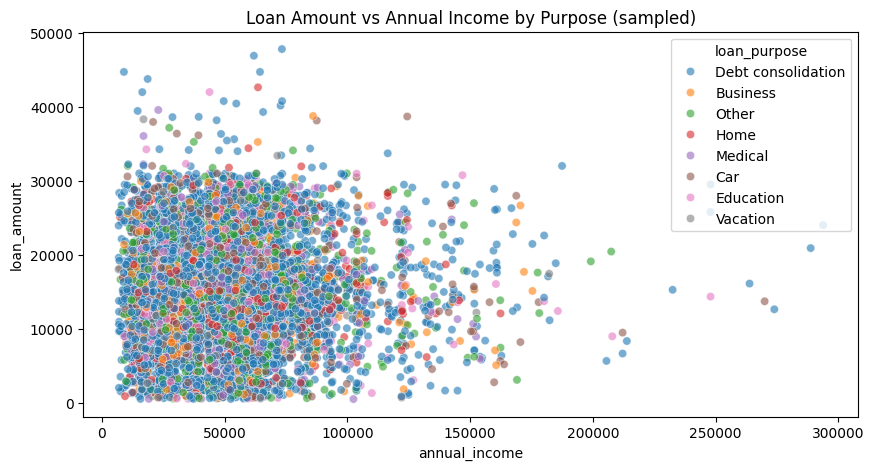

In [29]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=train.sample(10000), 
    x='annual_income', 
    y='loan_amount', 
    hue='loan_purpose', 
    alpha=0.6
)
plt.title("Loan Amount vs Annual Income by Purpose (sampled)")
plt.show()


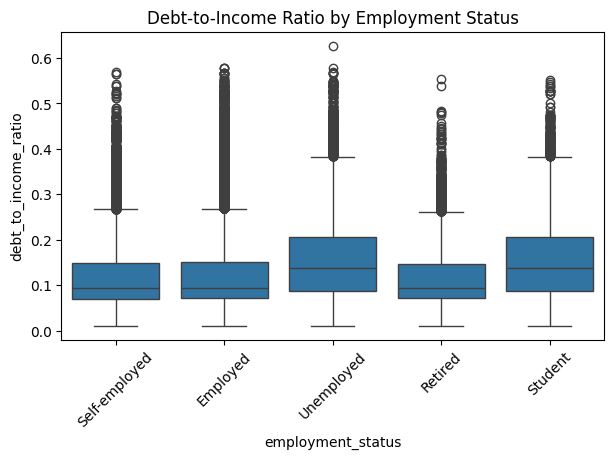

In [30]:
plt.figure(figsize=(7,4))
sns.boxplot(data=train, x='employment_status', y='debt_to_income_ratio')
plt.title("Debt-to-Income Ratio by Employment Status")
plt.xticks(rotation=45)
plt.show()


C:\Users\16yas\AppData\Local\Temp\ipykernel_13932\4271979223.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_default = train.groupby('credit_bin')['loan_paid_back'].mean()
C:\Users\16yas\AppData\Local\Temp\ipykernel_13932\4271979223.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate_default = train.groupby('rate_bin')['loan_paid_back'].mean()


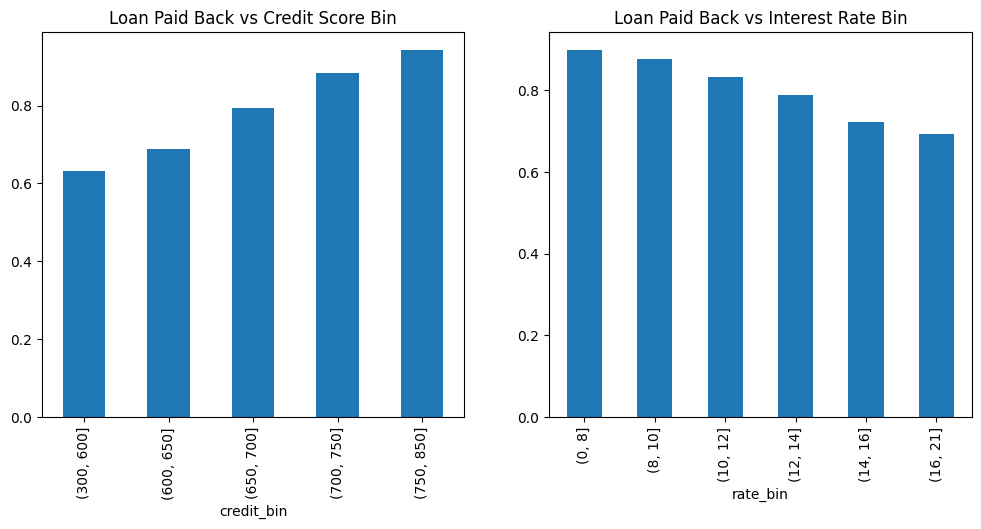

In [31]:
train['credit_bin'] = pd.cut(train['credit_score'], bins=[300,600,650,700,750,850])
credit_default = train.groupby('credit_bin')['loan_paid_back'].mean()

train['rate_bin'] = pd.cut(train['interest_rate'], bins=[0,8,10,12,14,16,21])
rate_default = train.groupby('rate_bin')['loan_paid_back'].mean()

fig, ax = plt.subplots(1,2, figsize=(12,5))
credit_default.plot(kind='bar', ax=ax[0], title='Loan Paid Back vs Credit Score Bin')
rate_default.plot(kind='bar', ax=ax[1], title='Loan Paid Back vs Interest Rate Bin')
plt.show()


C:\Users\16yas\AppData\Local\Temp\ipykernel_13932\2673280172.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = heat.pivot_table(index='credit_bin', columns='rate_bin', values='loan_paid_back')


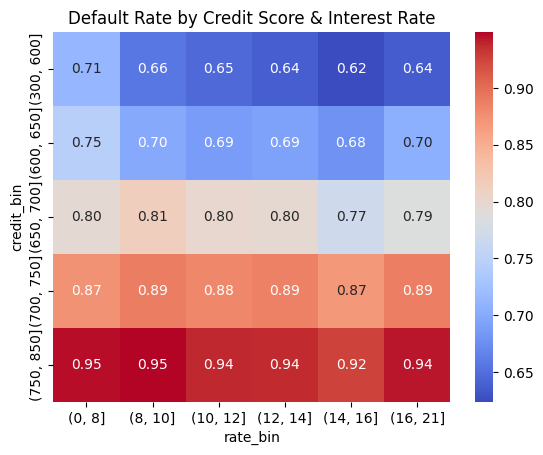

In [32]:
heat = train.copy()
heat['credit_bin'] = pd.cut(heat['credit_score'], bins=[300,600,650,700,750,850])
heat['rate_bin'] = pd.cut(heat['interest_rate'], bins=[0,8,10,12,14,16,21])
pivot = heat.pivot_table(index='credit_bin', columns='rate_bin', values='loan_paid_back')
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Default Rate by Credit Score & Interest Rate")
plt.show()


In [34]:
from scipy.stats import pointbiserialr

for col in ['annual_income','debt_to_income_ratio','credit_score','loan_amount','interest_rate']:
    corr, p = pointbiserialr(train[col], train['loan_paid_back'])
    print(f"{col}: corr={corr:.3f}, p={p:.4f}")


annual_income: corr=0.006, p=0.0000
debt_to_income_ratio: corr=-0.336, p=0.0000
credit_score: corr=0.235, p=0.0000
loan_amount: corr=-0.004, p=0.0037
interest_rate: corr=-0.131, p=0.0000


In [35]:
train

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,credit_bin,rate_bin
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,"(700, 750]","(12, 14]"
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,"(600, 650]","(12, 14]"
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,"(650, 700]","(8, 10]"
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,"(300, 600]","(16, 21]"
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,"(650, 700]","(10, 12]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0,"(700, 750]","(10, 12]"
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0,"(300, 600]","(14, 16]"
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0,"(650, 700]","(14, 16]"
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0,"(700, 750]","(8, 10]"


In [45]:
pd.read_csv(r'../playground-series-s5e11/train.csv')

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ==================================================
# 1️⃣ Load dataset
# ==================================================
data = pd.read_csv(r'../playground-series-s5e11/train.csv')
def preprocessing(data, is_test=False):
    # ==================================================
    # 2️⃣ Numerical Transformations
    # ==================================================
    for col in ['annual_income', 'loan_amount']:
        data[col] = np.log1p(data[col])  # safe log transform

    # Winsorize DTI
    data['debt_to_income_ratio'] = np.clip(data['debt_to_income_ratio'], 0, 1)

    # ==================================================
    # 3️⃣ Encode grade/subgrade to ordinal numeric
    # ==================================================
    grade_order = sorted(data['grade_subgrade'].dropna().unique(), key=lambda x: (x[0], int(x[1])))
    grade_map = {grade: i + 1 for i, grade in enumerate(grade_order)}
    data['grade_numeric'] = data['grade_subgrade'].map(grade_map)

    # ==================================================
    # 4️⃣ Derived / Composite Features
    # ==================================================
    data['loan_to_income_ratio'] = data['loan_amount'] / data['annual_income']
    data['income_to_loan_ratio'] = data['annual_income'] / data['loan_amount']
    data['credit_to_income_ratio'] = data['credit_score'] / data['annual_income']
    data['interest_per_credit'] = data['interest_rate'] / data['credit_score']
    data['dti_x_interest'] = data['debt_to_income_ratio'] * data['interest_rate']

    # ==================================================
    # 5️⃣ Interaction Features
    # ==================================================
    data['income_rate_ratio'] = data['annual_income'] / (data['interest_rate'] + 1)
    data['loan_credit_interaction'] = data['loan_amount'] * data['credit_score']

    # ==================================================
    # 6️⃣ Define Feature Sets
    # ==================================================
    num_features = [
        'credit_score', 'annual_income', 'loan_amount', 'debt_to_income_ratio',
        'interest_rate', 'loan_to_income_ratio', 'income_to_loan_ratio',
        'credit_to_income_ratio', 'interest_per_credit', 'dti_x_interest',
        'income_rate_ratio', 'loan_credit_interaction', 'grade_numeric'
    ]

    cat_features = [
        'employment_status', 'loan_purpose', 'marital_status',
        'gender', 'education_level'
    ]

    # Target column
    target = 'loan_paid_back'

    # ==================================================
    # 7️⃣ Preprocessing Pipelines
    # ==================================================
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_features),
            ('cat', cat_transformer, cat_features)
        ]
    )

    # ==================================================
    # 8️⃣ Fit-transform (exclude ID, target)
    # ==================================================
    X = data[num_features + cat_features]
    if not is_test:
        y = data[target]

    X_processed = preprocessor.fit_transform(X)

    # ==================================================
    # 9️⃣ Retrieve feature names
    # ==================================================
    num_cols = num_features
    cat_cols = list(
        preprocessor.named_transformers_['cat']
        .named_steps['encoder']
        .get_feature_names_out(cat_features)
    )

    all_feature_names = num_cols + cat_cols

    # Convert to DataFrame
    processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

    # Add target & ID back
    processed_df['id'] = data['id'].values
    if not is_test:
        processed_df['loan_paid_back'] = y.values

    # ==================================================
    # 🔎 Inspect
    # ==================================================
    print("✅ Feature engineering complete!")
    print(f"Total features created: {processed_df.shape[1]}")
    processed_df.head(3)
    return processed_df, all_feature_names


In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Convert preprocessed data (numeric only) to DataFrame first
numeric_df = pd.DataFrame(
    preprocessor.named_transformers_['num']
    .named_steps['scaler']
    .transform(
        data[num_features].fillna(data[num_features].median())
    ),
    columns=num_features
)

# === 1️⃣ Correlation-based filtering ===
corr_matrix = numeric_df.corr().abs()

# upper triangle mask
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop features with correlation > 0.9
high_corr_features = [column for column in upper.columns if any(upper[column] > 0.9)]
print(f"🔸 Highly correlated (>0.9) features to drop: {high_corr_features}")

numeric_df.drop(columns=high_corr_features, inplace=True)
num_features = [f for f in num_features if f not in high_corr_features]

# === 2️⃣ VIF-based filtering ===
def calculate_vif(df):
    vif = pd.DataFrame()
    vif["feature"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif

vif_df = calculate_vif(numeric_df)
print("🔹 Initial VIFs:\n", vif_df)

# Drop features with VIF > 10
while vif_df['VIF'].max() > 10:
    drop_feat = vif_df.loc[vif_df['VIF'].idxmax(), 'feature']
    print(f"🚫 Dropping {drop_feat} (VIF={vif_df['VIF'].max():.2f})")
    numeric_df.drop(columns=[drop_feat], inplace=True)
    vif_df = calculate_vif(numeric_df)

print("✅ Remaining numeric features after VIF filtering:")
print(list(numeric_df.columns))


d:\Dsoft\Projects\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


🔸 Highly correlated (>0.9) features to drop: ['income_to_loan_ratio', 'interest_per_credit', 'dti_x_interest', 'income_rate_ratio']
🔹 Initial VIFs:
                    feature         VIF
0             credit_score  461.313696
1            annual_income  125.618424
2              loan_amount  361.778908
3     debt_to_income_ratio    1.003990
4            interest_rate    1.408216
5     loan_to_income_ratio  344.050451
6   credit_to_income_ratio  360.408282
7  loan_credit_interaction  361.950461
🚫 Dropping credit_score (VIF=461.31)
🚫 Dropping loan_amount (VIF=352.20)
🚫 Dropping annual_income (VIF=93.98)
✅ Remaining numeric features after VIF filtering:
['debt_to_income_ratio', 'interest_rate', 'loan_to_income_ratio', 'credit_to_income_ratio', 'loan_credit_interaction']


Class distribution:
 loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64

Class ratio: 0.2518


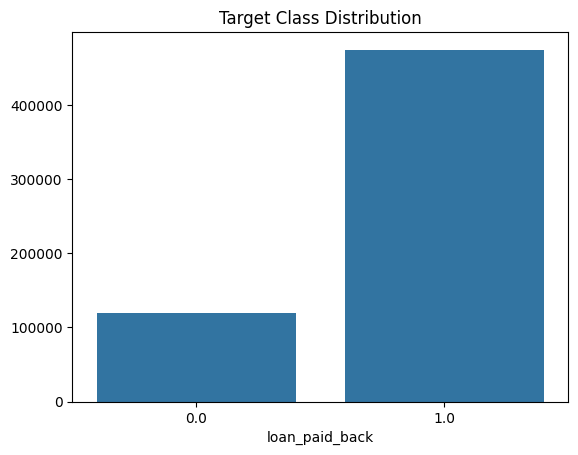

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Replace with your target column name
target_col = 'loan_paid_back'

class_counts = df[target_col].value_counts()
print("Class distribution:\n", class_counts)
print("\nClass ratio:", round(class_counts.min() / class_counts.max(), 4))

sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Target Class Distribution")
plt.show()


In [2]:
processed_df

NameError: name 'processed_df' is not defined

✅ Feature engineering complete!
Total features created: 40
✅ Feature engineering complete!
Total features created: 39
--- Fold 1/5 ---

🔹 LightGBM Performance:
ROC-AUC: 0.9226652056992015
              precision    recall  f1-score   support

         0.0       0.64      0.79      0.71     23900
         1.0       0.94      0.89      0.92     94899

    accuracy                           0.87    118799
   macro avg       0.79      0.84      0.81    118799
weighted avg       0.88      0.87      0.87    118799

[[18904  4996]
 [10605 84294]]
[0]	validation_0-auc:0.90611
[722]	validation_0-auc:0.92201

🔹 XGBoost Performance:
ROC-AUC: 0.9220743346119002
              precision    recall  f1-score   support

         0.0       0.64      0.79      0.71     23900
         1.0       0.94      0.89      0.92     94899

    accuracy                           0.87    118799
   macro avg       0.79      0.84      0.81    118799
weighted avg       0.88      0.87      0.87    118799

[[18864  5036]


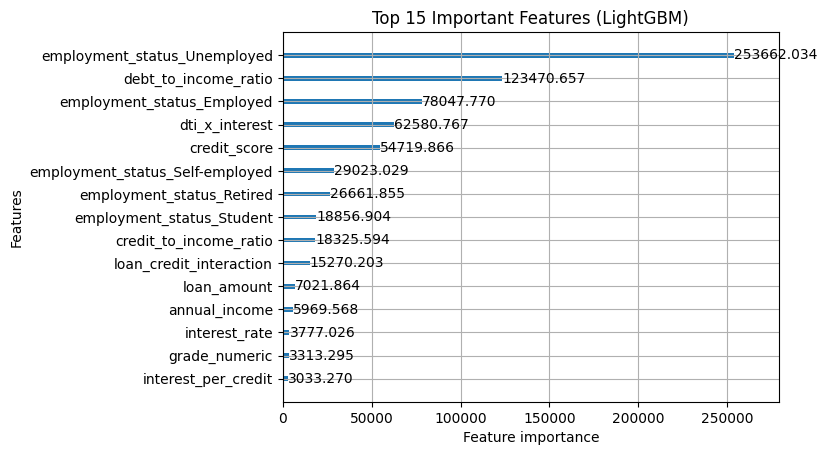

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

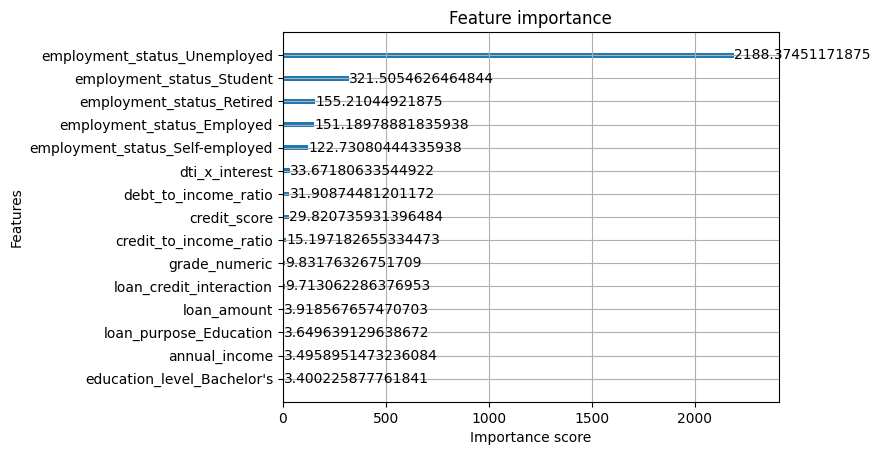

In [33]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

skf = StratifiedKFold(random_state=42, shuffle=True, n_splits=5)

oof_preds_lgb = np.zeros(len(X))
oof_preds_xgb = np.zeros(len(X))

processed_df, all_cols = preprocessing(data=train_org)
processed_test = preprocessing(test_org, True)

# 🧩 Step 1: Split data
X = processed_df.drop('loan_paid_back', axis=1)  # replace with your target column
X = X.drop('id', axis=1)  # replace with your target column
y = processed_df['loan_paid_back']

X[all_cols] = X[all_cols].astype('float64')
# X[cat_cols] = X[cat_cols].astype('category')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{5} ---')

    X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

    # X_train, X_test, y_train, y_test = train_test_split(
    #     X, y, test_size=0.2, random_state=42, stratify=y
    # )

    # ----------------------------------------------------------
    # ⚡ Option 1: LightGBM
    # ----------------------------------------------------------
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        reg_lambda=0,
        reg_alpha=0.5,
        subsample=0.8,
        min_child_samples=75,
        colsample_bytree=0.6,
        random_state=42,
        scale_pos_weight=1/3.9706515242080096,
        n_jobs=-1,
        early_stopping_rounds=50,
        verbose=-1
    )

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc'
    )

    y_pred_lgb = lgb_model.predict(X_test)
    y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

    print("\n🔹 LightGBM Performance:")
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lgb))
    oof_preds_lgb[val_idx] = lgb_model.predict_proba(X_test, num_iteration=lgb_model.best_iteration_)[:, 1]
    print(classification_report(y_test, y_pred_lgb))
    print(confusion_matrix(y_test, (y_pred_lgb > 0.5).astype(int)))

    # ----------------------------------------------------------
    # ⚡ Option 2: XGBoost
    # ----------------------------------------------------------
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=1/3.9706515242080096,
        early_stopping_rounds=50,
        eval_metric='auc',
        enable_categorical=True
    )

    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=1000
    )

    y_pred_xgb = xgb_model.predict(X_test)
    y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

    print("\n🔹 XGBoost Performance:")
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
    print(classification_report(y_test, y_pred_xgb))
    oof_preds_xgb[val_idx] = xgb_model.predict_proba(X_test, iteration_range=[0,xgb_model.best_iteration])[:, 1]
    print(confusion_matrix(y_test, (y_pred_xgb > 0.5).astype(int)))

print("OOF AUC: LGBM:", roc_auc_score(y, oof_preds_lgb))
print("OOF AUC: XGB", roc_auc_score(y, oof_preds_xgb))


# ----------------------------------------------------------
# 🔍 Feature Importance (example for LightGBM)
# ----------------------------------------------------------
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, max_num_features=15, importance_type='gain')
plt.title("Top 15 Important Features (LightGBM)")
plt.show()

xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain')


✅ Feature engineering complete!
Total features created: 40
✅ Feature engineering complete!
Total features created: 39
--- Fold 1/5 ---

🔹 LightGBM Performance:
ROC-AUC: 0.9227884871742744
              precision    recall  f1-score   support

         0.0       0.73      0.74      0.73     23900
         1.0       0.93      0.93      0.93     94899

    accuracy                           0.89    118799
   macro avg       0.83      0.83      0.83    118799
weighted avg       0.89      0.89      0.89    118799

[[17665  6235]
 [ 6600 88299]]
--- Fold 2/5 ---

🔹 LightGBM Performance:
ROC-AUC: 0.9227653310868578
              precision    recall  f1-score   support

         0.0       0.73      0.74      0.74     23900
         1.0       0.93      0.93      0.93     94899

    accuracy                           0.89    118799
   macro avg       0.83      0.83      0.83    118799
weighted avg       0.89      0.89      0.89    118799

[[17619  6281]
 [ 6417 88482]]
--- Fold 3/5 ---

🔹 LightG

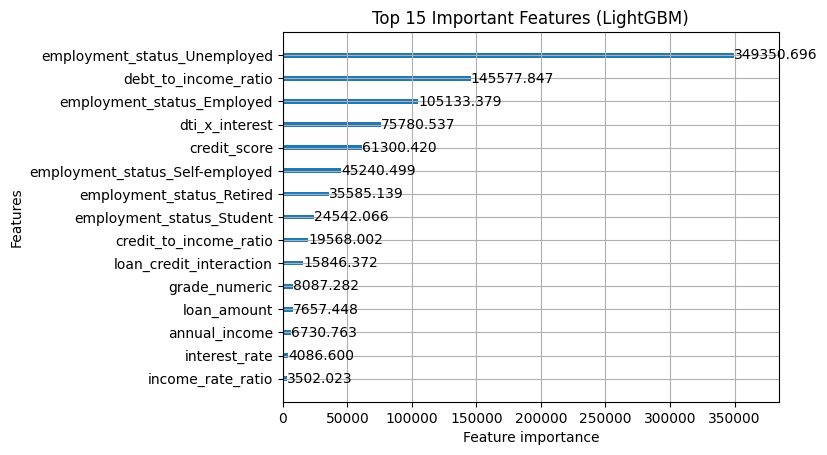

In [39]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

skf = StratifiedKFold(random_state=42, shuffle=True, n_splits=5)

processed_df, all_cols = preprocessing(data=train_org)
processed_test, test_cols = preprocessing(test_org, True)

# 🧩 Step 1: Split data
X = processed_df.drop('loan_paid_back', axis=1)  # replace with your target column
X = X.drop('id', axis=1)  # replace with your target column
y = processed_df['loan_paid_back']

X_res = processed_test.drop('id', axis=1)  # Assuming test set doesn't have target
X_res[test_cols] = X[test_cols].astype('float64')
X_id = processed_test['id']

oof_preds_lgb = np.zeros(len(X))
# oof_preds_xgb = np.zeros(len(X))
test_preds = np.zeros(len(test))

X[all_cols] = X[all_cols].astype('float64')
# X[cat_cols] = X[cat_cols].astype('category')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{5} ---')

    X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

    # X_train, X_test, y_train, y_test = train_test_split(
    #     X, y, test_size=0.2, random_state=42, stratify=y
    # )

    # ----------------------------------------------------------
    # ⚡ Option 1: LightGBM
    # ----------------------------------------------------------
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        reg_lambda=0,
        reg_alpha=0.5,
        subsample=0.8,
        min_child_samples=75,
        colsample_bytree=0.6,
        random_state=42,
        scale_pos_weight=1/2.5,
        n_jobs=-1,
        early_stopping_rounds=50,
        verbose=-1
    )

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc'
    )
    
    y_pred_lgb = lgb_model.predict(X_test)
    y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
    test_preds += lgb_model.predict_proba(X_res)[:, 1]

    print("\n🔹 LightGBM Performance:")
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lgb))

    oof_preds_lgb[val_idx] = lgb_model.predict_proba(X_test, num_iteration=lgb_model.best_iteration_)[:, 1]
    print(classification_report(y_test, y_pred_lgb))
    print(confusion_matrix(y_test, (y_pred_lgb > 0.5).astype(int)))

    # ----------------------------------------------------------
    # ⚡ Option 2: XGBoost
    # ----------------------------------------------------------
    # xgb_model = xgb.XGBClassifier(
    #     objective='binary:logistic',
    #     n_estimators=1000,
    #     learning_rate=0.05,
    #     max_depth=6,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     random_state=42,
    #     n_jobs=-1,
    #     scale_pos_weight=1/3.9706515242080096,
    #     early_stopping_rounds=50,
    #     eval_metric='auc',
    #     enable_categorical=True
    # )

    # xgb_model.fit(
    #     X_train, y_train,
    #     eval_set=[(X_test, y_test)],
    #     verbose=1000
    # )

    # y_pred_xgb = xgb_model.predict(X_test)
    # y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

    # print("\n🔹 XGBoost Performance:")
    # print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
    # print(classification_report(y_test, y_pred_xgb))
    # oof_preds_xgb[val_idx] = xgb_model.predict_proba(X_test, iteration_range=[0,xgb_model.best_iteration])[:, 1]
    # print(confusion_matrix(y_test, (y_pred_xgb > 0.5).astype(int)))

print(f'====================')
print("OOF AUC: LGBM:", roc_auc_score(y, oof_preds_lgb))
print(f'Overall OOF AUC rounded to 4: {roc_auc_score(y, oof_preds_lgb):.4f}')
# print("OOF AUC: XGB", roc_auc_score(y, oof_preds_xgb))
print(f'====================')


# ----------------------------------------------------------
# 🔍 Feature Importance (example for LightGBM)
# ----------------------------------------------------------
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, max_num_features=15, importance_type='gain')
plt.title("Top 15 Important Features (LightGBM)")
plt.show()

# xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain')


✅ Feature engineering complete!
Total features created: 40
✅ Feature engineering complete!
Total features created: 39
--- Fold 1/5 ---
[0. 0. 0. 0. 0.]

🔹 LightGBM Performance:
ROC-AUC: 0.9229102766424961
              precision    recall  f1-score   support

         0.0       0.73      0.74      0.73     23900
         1.0       0.93      0.93      0.93     94899

    accuracy                           0.89    118799
   macro avg       0.83      0.83      0.83    118799
weighted avg       0.89      0.89      0.89    118799

[[17677  6223]
 [ 6636 88263]]
--- Fold 2/5 ---
[0.19044717 0.07038332 0.16979426 0.12965099 0.18702261]

🔹 LightGBM Performance:
ROC-AUC: 0.9227469592093528
              precision    recall  f1-score   support

         0.0       0.73      0.74      0.74     23900
         1.0       0.93      0.93      0.93     94899

    accuracy                           0.89    118799
   macro avg       0.83      0.83      0.83    118799
weighted avg       0.89      0.89     

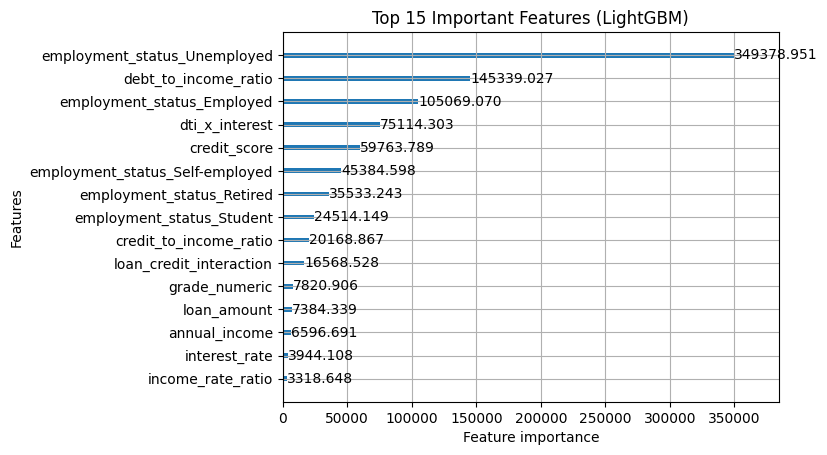

In [53]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

skf = StratifiedKFold(random_state=42, shuffle=True, n_splits=5)

processed_df, all_cols = preprocessing(data=train_org.copy())
processed_test, test_cols = preprocessing(test_org.copy(), True)

# 🧩 Step 1: Split data
X = processed_df.drop('loan_paid_back', axis=1)  # replace with your target column
X = X.drop('id', axis=1)  # replace with your target column
y = processed_df['loan_paid_back']

X_res = processed_test.drop('id', axis=1)  # Assuming test set doesn't have target
X_res[test_cols] = X[test_cols].astype('float64')
X_id = processed_test['id']

oof_preds_lgb = np.zeros(len(X))
# oof_preds_xgb = np.zeros(len(X))
test_preds = np.zeros(len(test))

X[all_cols] = X[all_cols].astype('float64')
# X[cat_cols] = X[cat_cols].astype('category')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{5} ---')

    X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

    # X_train, X_test, y_train, y_test = train_test_split(
    #     X, y, test_size=0.2, random_state=42, stratify=y
    # )

    # ----------------------------------------------------------
    # ⚡ Option 1: LightGBM
    # ----------------------------------------------------------
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        reg_lambda=0,
        reg_alpha=0.5,
        subsample=0.8,
        min_child_samples=75,
        colsample_bytree=0.6,
        random_state=42,
        scale_pos_weight=1/2.5,
        n_jobs=-1,
        early_stopping_rounds=50,
        verbose=-1
    )

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc'
    )
    
    y_pred_lgb = lgb_model.predict(X_test)
    y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
    print(test_preds[0:5])
    test_preds += lgb_model.predict_proba(X_res)[:, 1] / 5

    print("\n🔹 LightGBM Performance:")
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lgb))

    oof_preds_lgb[val_idx] = lgb_model.predict_proba(X_test)[:, 1]
    print(classification_report(y_test, y_pred_lgb))
    print(confusion_matrix(y_test, (y_pred_lgb > 0.5).astype(int)))

    # ----------------------------------------------------------
    # ⚡ Option 2: XGBoost
    # ----------------------------------------------------------
    # xgb_model = xgb.XGBClassifier(
    #     objective='binary:logistic',
    #     n_estimators=1000,
    #     learning_rate=0.05,
    #     max_depth=6,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     random_state=42,
    #     n_jobs=-1,
    #     scale_pos_weight=1/3.9706515242080096,
    #     early_stopping_rounds=50,
    #     eval_metric='auc',
    #     enable_categorical=True
    # )

    # xgb_model.fit(
    #     X_train, y_train,
    #     eval_set=[(X_test, y_test)],
    #     verbose=1000
    # )

    # y_pred_xgb = xgb_model.predict(X_test)
    # y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

    # print("\n🔹 XGBoost Performance:")
    # print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
    # print(classification_report(y_test, y_pred_xgb))
    # oof_preds_xgb[val_idx] = xgb_model.predict_proba(X_test, iteration_range=[0,xgb_model.best_iteration])[:, 1]
    # print(confusion_matrix(y_test, (y_pred_xgb > 0.5).astype(int)))

print(f'====================')
print("OOF AUC: LGBM:", roc_auc_score(y, oof_preds_lgb))
print(f'Overall OOF AUC rounded to 4: {roc_auc_score(y, oof_preds_lgb):.4f}')
# print("OOF AUC: XGB", roc_auc_score(y, oof_preds_xgb))
print(f'====================')


# ----------------------------------------------------------
# 🔍 Feature Importance (example for LightGBM)
# ----------------------------------------------------------
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, max_num_features=15, importance_type='gain')
plt.title("Top 15 Important Features (LightGBM)")
plt.show()

# xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain')


In [142]:
def add_dti_loan_interest_interaction(x):
    x["combined_metric"] = (
        np.log10(x['annual_income']) * \
        np.log10(x['loan_amount']) * \
        x["debt_to_income_ratio"]
    )
    return x

✅ Feature engineering complete!
Total features created: 40
✅ Feature engineering complete!
Total features created: 39


d:\Dsoft\Projects\ML\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
d:\Dsoft\Projects\ML\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


--- Fold 1/5 ---

🔹 LightGBM Performance:
ROC-AUC: 0.922757859589193
              precision    recall  f1-score   support

         0.0       0.74      0.73      0.73     23900
         1.0       0.93      0.94      0.93     94899

    accuracy                           0.89    118799
   macro avg       0.84      0.83      0.83    118799
weighted avg       0.89      0.89      0.89    118799

[[17374  6526]
 [ 6012 88887]]
--- Fold 2/5 ---

🔹 LightGBM Performance:
ROC-AUC: 0.922493793776171
              precision    recall  f1-score   support

         0.0       0.75      0.73      0.74     23900
         1.0       0.93      0.94      0.93     94899

    accuracy                           0.90    118799
   macro avg       0.84      0.83      0.84    118799
weighted avg       0.89      0.90      0.90    118799

[[17362  6538]
 [ 5859 89040]]
--- Fold 3/5 ---

🔹 LightGBM Performance:
ROC-AUC: 0.9208302123098412
              precision    recall  f1-score   support

         0.0       0.

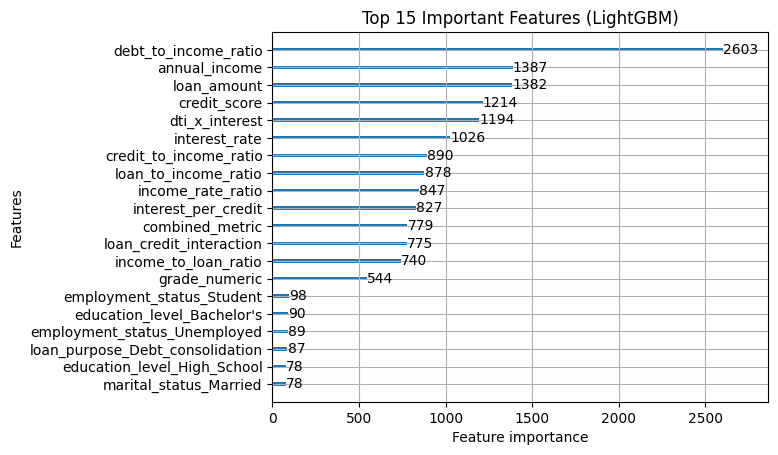

In [154]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

skf = StratifiedKFold(random_state=42, shuffle=True, n_splits=5)

processed_df, all_cols = preprocessing(data=train_org)
processed_test, test_cols = preprocessing(test_org, True)

processed_df = add_dti_loan_interest_interaction(processed_df)
processed_test = add_dti_loan_interest_interaction(processed_test)
# 🧩 Step 1: Split data
X = processed_df.drop('loan_paid_back', axis=1)  # replace with your target column
X = X.drop('id', axis=1)  # replace with your target column
y = processed_df['loan_paid_back']

X_res = processed_test.drop('id', axis=1)  # Assuming test set doesn't have target
X_res[test_cols] = X[test_cols].astype('float64')
X_id = processed_test['id']

oof_preds_lgb = np.zeros(len(X))
# oof_preds_xgb = np.zeros(len(X))
test_preds = np.zeros(len(test))



X[all_cols] = X[all_cols].astype('float64')
# X[cat_cols] = X[cat_cols].astype('category')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{5} ---')

    X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------------------------------------
    # ⚡ Option 1: LightGBM
    # ----------------------------------------------------------
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=10000,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        reg_lambda=0,
        reg_alpha=0.5,
        subsample=0.8,
        min_child_samples=75,
        colsample_bytree=0.6,
        random_state=42,
        scale_pos_weight=1/2.3,
        # is_unbalance=True,
        n_jobs=-1,
        early_stopping_rounds=150,
        verbose=-1
    )

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc'
    )
    
    y_pred_lgb = lgb_model.predict(X_test)
    y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
    test_preds += lgb_model.predict_proba(X_res)[:, 1]

    print("\n🔹 LightGBM Performance:")
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lgb))

    oof_preds_lgb[val_idx] = lgb_model.predict_proba(X_test, num_iteration=lgb_model.best_iteration_)[:, 1]
    print(classification_report(y_test, y_pred_lgb))
    print(confusion_matrix(y_test, (y_pred_lgb > 0.5).astype(int)))


print(f'====================')
print("OOF AUC: LGBM:", roc_auc_score(y, oof_preds_lgb))
print(f'Overall OOF AUC rounded to 4: {roc_auc_score(y, oof_preds_lgb):.4f}')
# print("OOF AUC: XGB", roc_auc_score(y, oof_preds_xgb))
print(f'====================')


# ----------------------------------------------------------
# 🔍 Feature Importance (example for LightGBM)
# ----------------------------------------------------------
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, max_num_features=20)
plt.title("Top 15 Important Features (LightGBM)")
plt.show()

# xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain')


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

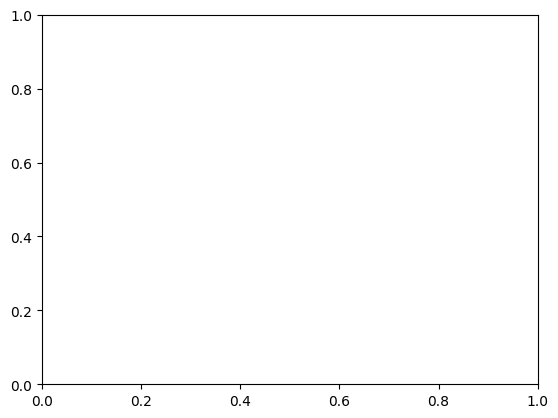

In [150]:
lgb.plot_tree(lgb_model)

In [50]:
pd.DataFrame({
    'id': X_id,
    'loan_paid_back': test_preds
}).to_csv(r'../submission002.csv', index=False)

In [49]:
pd.read_parquet(r'../submission002.parquet')

,id,loan_paid_back
0,593994,0.962120
1,593995,0.371313
2,593996,0.855017
3,593997,0.673979
4,593998,0.935554
...,...,...
254564,848558,0.691230
254565,848559,0.996041
254566,848560,0.328561
254567,848561,0.379942


In [55]:
X[cat_cols].value_counts()

employment_status_Employed  employment_status_Retired  employment_status_Self-employed  employment_status_Student  employment_status_Unemployed  loan_purpose_Business  loan_purpose_Car  loan_purpose_Debt consolidation  loan_purpose_Education  loan_purpose_Home  loan_purpose_Medical  loan_purpose_Other  loan_purpose_Vacation  marital_status_Divorced  marital_status_Married  marital_status_Single  marital_status_Widowed  gender_Female  gender_Male  gender_Other  education_level_Bachelor's  education_level_High School  education_level_Master's  education_level_Other  education_level_PhD
1.0                         0.0                        0.0                              0.0                        0.0                           0.0                    0.0               1.0                              0.0                     0.0                0.0                   0.0                 0.0                    0.0                      0.0                     1.0                    0.0       

In [22]:
print(xgb.__version__)

3.1.1


In [67]:
mask = train_org['loan_paid_back']==0
train_org[mask].shape

(119500, 13)

In [64]:
train_org.sort_values(by=['loan_paid_back', 'employment_status', 'loan_purpose', 'grade_subgrade'], ascending=[True, False, True, False]).head(60)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
4769,4769,76939.58,0.215,565,16160.78,14.83,Female,Single,Other,Unemployed,Business,F5,0.0
24731,24731,54418.95,0.085,576,25563.15,11.89,Female,Married,Bachelor's,Unemployed,Business,F5,0.0
46174,46174,25202.65,0.297,554,9142.70,14.95,Female,Married,Bachelor's,Unemployed,Business,F5,0.0
48011,48011,71269.09,0.216,554,16700.03,16.16,Male,Married,Bachelor's,Unemployed,Business,F5,0.0
65067,65067,54546.78,0.248,546,12982.31,15.92,Male,Single,High School,Unemployed,Business,F5,0.0
65839,65839,93904.69,0.205,568,12253.23,13.78,Male,Single,Bachelor's,Unemployed,Business,F5,0.0
73226,73226,56900.61,0.322,568,30281.12,11.97,Male,Single,Other,Unemployed,Business,F5,0.0
80048,80048,48389.20,0.268,561,2779.89,14.40,Male,Single,Bachelor's,Unemployed,Business,F5,0.0
81629,81629,67852.88,0.245,573,3182.65,12.49,Female,Married,Master's,Unemployed,Business,F5,0.0
87492,87492,38768.91,0.093,535,12642.76,18.44,Male,Married,Other,Unemployed,Business,F5,0.0


In [ ]:
featured_df = train_org.copy()
featured_df['high_risk_combo'] = (
    (featured_df['employment_status'].isin(['Unemployed', 'Student'])) &
    (featured_df['education_level'].isin(['High School', 'Other'])) &
    (featured_df['marital_status'].isin(['Single', 'Divorced', 'Widowed'])) &
    (featured_df['loan_purpose'].isin(['Medical', 'Education', 'Vacation', 'Other'])) &
    (featured_df['grade_subgrade'].str[0].isin(['D', 'E', 'F']))
)

In [68]:
# Persoanal Analysis: High risk combination feature

mask = train_org['loan_paid_back']==0
train_org[mask].shape

(119500, 13)

In [71]:
train_org[mask].employment_status.value_counts()

employment_status
Unemployed       57635
Employed         47703
Student           8787
Self-employed     5329
Retired             46
Name: count, dtype: int64

In [76]:
train_org[mask][train_org.employment_status == 'Retired'].loan_purpose.value_counts()

C:\Users\16yas\AppData\Local\Temp\ipykernel_48140\2563832474.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  train_org[mask][train_org.employment_status == 'Retired'].loan_purpose.value_counts()


loan_purpose
Debt consolidation    28
Car                    8
Home                   6
Education              2
Business               1
Medical                1
Name: count, dtype: int64

In [77]:
train_org[mask].loan_purpose.value_counts()

loan_purpose
Debt consolidation    65942
Other                 12623
Car                   11585
Education              8169
Home                   7799
Business               6598
Medical                5061
Vacation               1723
Name: count, dtype: int64

In [78]:
train_org[mask].to_csv(r'../loan_unpaid.csv', index=False)

In [79]:
import pandas as pd

df_unpaid = pd.read_csv("../loan_unpaid.csv")

print("Shape:", df_unpaid.shape)
print("\nColumn Types:")
print(df_unpaid.dtypes)

print("\nMissing Values:")
print(df_unpaid.isna().sum())

print("\nCategorical Columns:")
cat_cols = df_unpaid.select_dtypes(include=['object', 'category']).columns.tolist()
print(cat_cols)

print("\nNumeric Columns:")
num_cols = df_unpaid.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_cols)

print("\nQuick stats of numeric columns:")
display(df_unpaid[num_cols].describe())


Shape: (119500, 13)

Column Types:
id                        int64
annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
interest_rate           float64
gender                   object
marital_status           object
education_level          object
employment_status        object
loan_purpose             object
grade_subgrade           object
loan_paid_back          float64
dtype: object

Missing Values:
id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

Categorical Columns:
['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

Numeric Columns:
['id', 'annual_income', 

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,119500.000000,119500.000000,119500.000000,119500.000000,119500.000000,119500.000000,119500.0
mean,296522.438678,47875.503881,0.166564,655.010628,15072.223883,12.881495,0.0
std,171854.487247,27199.060946,0.083245,51.680938,6945.374637,1.981273,0.0
min,1.000000,6098.800000,0.011000,395.000000,507.420000,3.890000,0.0
25%,147001.250000,27479.037500,0.093000,623.000000,10446.667500,11.550000,0.0
50%,296361.500000,45935.390000,0.165000,657.000000,15078.790000,12.875000,0.0
75%,445472.000000,59893.150000,0.220000,690.000000,19100.740000,14.170000,0.0
max,593986.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,0.0


In [80]:
import pandas as pd
import numpy as np

df = df_unpaid.copy()

# -------------------------
# NUMERIC DISTRIBUTIONS
# -------------------------
print("📌 Skewness of Numerical Columns:")
print(df[['annual_income','debt_to_income_ratio','credit_score','loan_amount','interest_rate']].skew())

print("\n📌 Top 10 High DTI Cases:")
display(df.nlargest(10, 'debt_to_income_ratio')[['annual_income','debt_to_income_ratio','loan_amount','credit_score']])

print("\n📌 Annual Income distribution:")
print(df['annual_income'].describe(percentiles=[0.9,0.95,0.99]))

print("\n📌 Loan Amount distribution:")
print(df['loan_amount'].describe(percentiles=[0.9,0.95,0.99]))

print("\n📌 Correlation Matrix:")
display(df[['annual_income','debt_to_income_ratio','credit_score','loan_amount','interest_rate']].corr())

# -------------------------
# CATEGORICAL FREQUENCIES
# -------------------------
print("\n📌 Value counts for categorical columns:")
for col in ['gender','marital_status','education_level','employment_status','loan_purpose','grade_subgrade']:
    print(f"\n---- {col} ----")
    print(df[col].value_counts(normalize=True).head(10))


📌 Skewness of Numerical Columns:
annual_income           1.893171
debt_to_income_ratio    0.733931
credit_score           -0.124782
loan_amount             0.207759
interest_rate           0.008207
dtype: float64

📌 Top 10 High DTI Cases:


,annual_income,debt_to_income_ratio,loan_amount,credit_score
91043,40796.82,0.627,5204.05,667
69624,42777.74,0.577,6802.62,585
73642,104027.72,0.577,7861.26,616
77508,43809.27,0.577,9393.83,678
76651,36159.30,0.569,2999.99,621
77638,43912.70,0.569,6574.20,669
2184,54073.77,0.566,15441.17,766
9046,74069.19,0.566,16008.60,609
67066,135701.71,0.566,13461.42,592
69883,15154.65,0.566,5697.75,631



📌 Annual Income distribution:
count    119500.000000
mean      47875.503881
std       27199.060946
min        6098.800000
50%       45935.390000
90%       76788.860000
95%       93830.790000
99%      145547.230000
max      393381.740000
Name: annual_income, dtype: float64

📌 Loan Amount distribution:
count    119500.000000
mean      15072.223883
std        6945.374637
min         507.420000
50%       15078.790000
90%       24795.669000
95%       27018.470000
99%       30308.070000
max       48959.950000
Name: loan_amount, dtype: float64

📌 Correlation Matrix:


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
annual_income,1.000000,0.002678,0.008293,-0.000283,-0.004283
debt_to_income_ratio,0.002678,1.000000,0.099476,-0.020771,-0.056186
credit_score,0.008293,0.099476,1.000000,-0.005604,-0.511116
loan_amount,-0.000283,-0.020771,-0.005604,1.000000,-0.000615
interest_rate,-0.004283,-0.056186,-0.511116,-0.000615,1.000000



📌 Value counts for categorical columns:

---- gender ----
gender
Female    0.508050
Male      0.485565
Other     0.006385
Name: proportion, dtype: float64

---- marital_status ----
marital_status
Single      0.486142
Married     0.465983
Divorced    0.036268
Widowed     0.011607
Name: proportion, dtype: float64

---- education_level ----
education_level
Bachelor's     0.493950
High School    0.292368
Master's       0.153983
Other          0.044025
PhD            0.015674
Name: proportion, dtype: float64

---- employment_status ----
employment_status
Unemployed       0.482301
Employed         0.399188
Student          0.073531
Self-employed    0.044594
Retired          0.000385
Name: proportion, dtype: float64

---- loan_purpose ----
loan_purpose
Debt consolidation    0.551816
Other                 0.105632
Car                   0.096946
Education             0.068360
Home                  0.065264
Business              0.055213
Medical               0.042351
Vacation              0.01

In [85]:
main = pd.read_csv(r'../playground-series-s5e11/train.csv')

In [86]:
main.loan_paid_back = main.loan_paid_back.astype('int8')

In [97]:
main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int16  
 1   annual_income         593994 non-null  float32
 2   debt_to_income_ratio  593994 non-null  float32
 3   credit_score          593994 non-null  int16  
 4   loan_amount           593994 non-null  float32
 5   interest_rate         593994 non-null  float32
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  int8   
dtypes: float32(4), int16(2), int8(1), object(6)
memory usage: 39.1+ MB


In [96]:
main.annual_income = main.annual_income.astype("float32")
main.debt_to_income_ratio = main.debt_to_income_ratio.astype("float32")
main.credit_score = main.credit_score.astype("int16")
main.loan_amount = main.loan_amount.astype("float32")
main.interest_rate = main.interest_rate.astype("float32")
main.id = main.id.astype("int16")

In [91]:
main

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.990234,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1
1,1,22108.019531,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0
2,2,49566.199219,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1
3,3,46858.250000,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1
4,4,25496.699219,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.259766,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1
593990,593990,35289.429688,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1
593991,593991,47112.640625,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1
593992,593992,76748.437500,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1


In [98]:
main.to_csv(r'../playground-series-s5e11/train_optimized.csv', index=False)

In [99]:
main.head(60)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.990234,0.084,736,2528.419922,13.670000,Female,Single,High School,Self-employed,Other,C3,1
1,1,22108.019531,0.166,636,4593.100098,12.920000,Male,Married,Master's,Employed,Debt consolidation,D3,0
2,2,49566.199219,0.097,694,17005.150391,9.760000,Male,Single,High School,Employed,Debt consolidation,C5,1
3,3,46858.250000,0.065,533,4682.479980,16.100000,Female,Single,High School,Employed,Debt consolidation,F1,1
4,4,25496.699219,0.053,665,12184.429688,10.210000,Male,Married,High School,Employed,Other,D1,1
5,5,44940.300781,0.058,653,12159.919922,12.240000,Male,Single,Bachelor's,Employed,Other,D1,1
6,6,61574.160156,0.042,696,16907.710938,13.520000,Other,Single,High School,Self-employed,Debt consolidation,C5,1
7,7,45953.308594,0.100,654,10111.620117,12.820000,Female,Married,High School,Employed,Home,D1,1
8,8,30592.289062,0.132,713,7522.359863,9.480000,Male,Married,Bachelor's,Employed,Education,C5,1
9,9,17342.449219,0.121,548,9653.480469,16.040001,Female,Married,Bachelor's,Self-employed,Vacation,F1,1


In [102]:
main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int16  
 1   annual_income         593994 non-null  float32
 2   debt_to_income_ratio  593994 non-null  float32
 3   credit_score          593994 non-null  int16  
 4   loan_amount           593994 non-null  float32
 5   interest_rate         593994 non-null  float32
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  int8   
dtypes: float32(4), int16(2), int8(1), object(6)
memory usage: 39.1+ MB


In [104]:
print(main['loan_paid_back'].value_counts(dropna=False))
print(main['loan_paid_back'].value_counts(normalize=True))


loan_paid_back
1    474494
0    119500
Name: count, dtype: int64
loan_paid_back
1    0.79882
0    0.20118
Name: proportion, dtype: float64


In [106]:
main.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,14.137269,48212.207031,0.120696,680.916009,15020.297852,12.356345,0.798820
std,18853.179134,26711.943359,0.068573,55.424956,6926.530273,2.008959,0.400883
min,-32768.000000,6002.430176,0.011000,395.000000,500.089996,3.200000,0.000000
25%,-16269.000000,27934.400391,0.072000,646.000000,10279.620117,10.990000,1.000000
50%,208.000000,46557.679688,0.096000,682.000000,15000.219727,12.370000,1.000000
75%,16268.000000,60981.320312,0.156000,719.000000,18858.580078,13.680000,1.000000
max,32767.000000,393381.750000,0.627000,849.000000,48959.949219,20.990000,1.000000


In [107]:
main[['annual_income','debt_to_income_ratio','credit_score',
    'loan_amount','interest_rate']].skew()


annual_income           1.719509
debt_to_income_ratio    1.406680
credit_score           -0.166993
loan_amount             0.207360
interest_rate           0.049945
dtype: float64

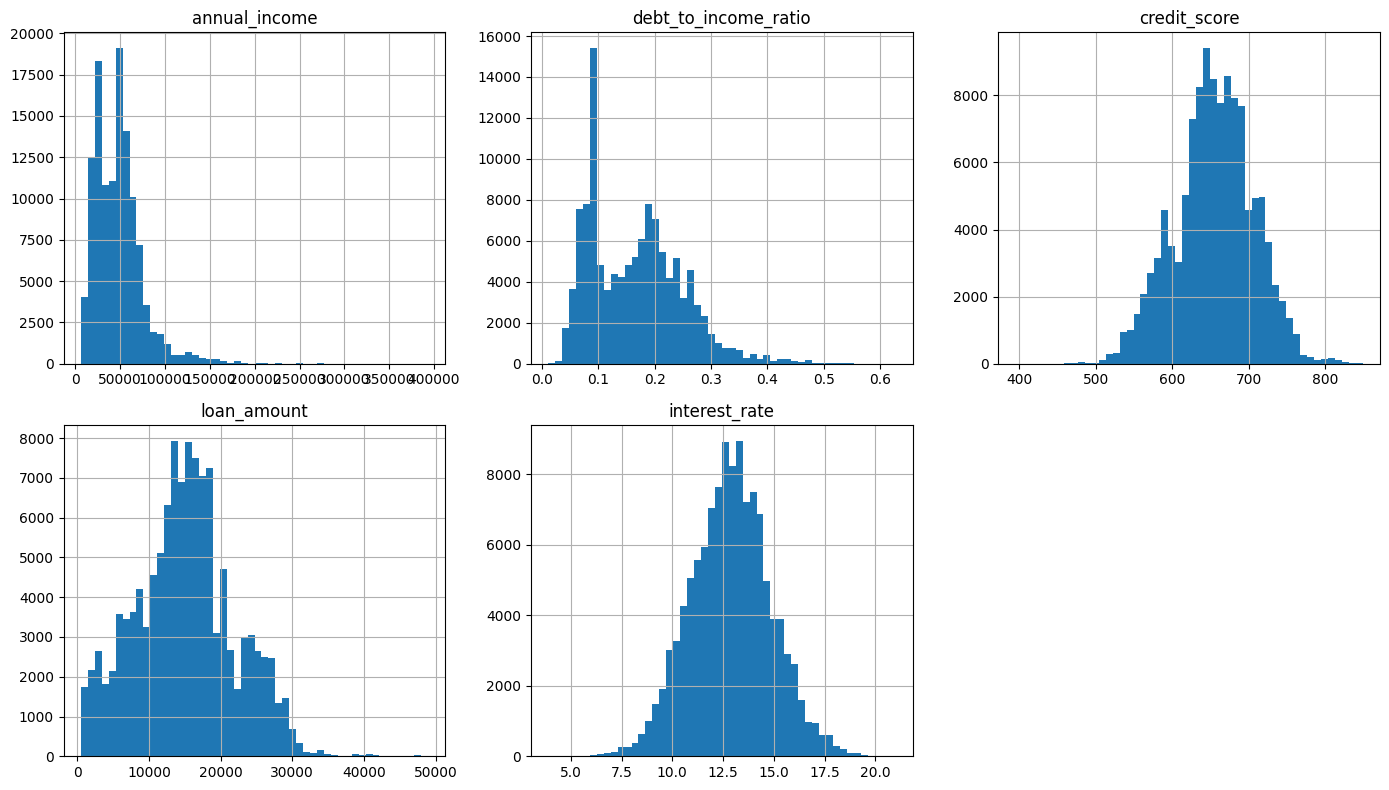

In [109]:
import matplotlib.pyplot as plt

num_cols = ['annual_income','debt_to_income_ratio','credit_score',
            'loan_amount','interest_rate']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))  # 2 rows × 3 columns
axes = axes.flatten()  # make indexing easier

for i, col in enumerate(num_cols):
    df[col].hist(bins=50, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot (only needed because we have 6 slots but 5 columns)
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


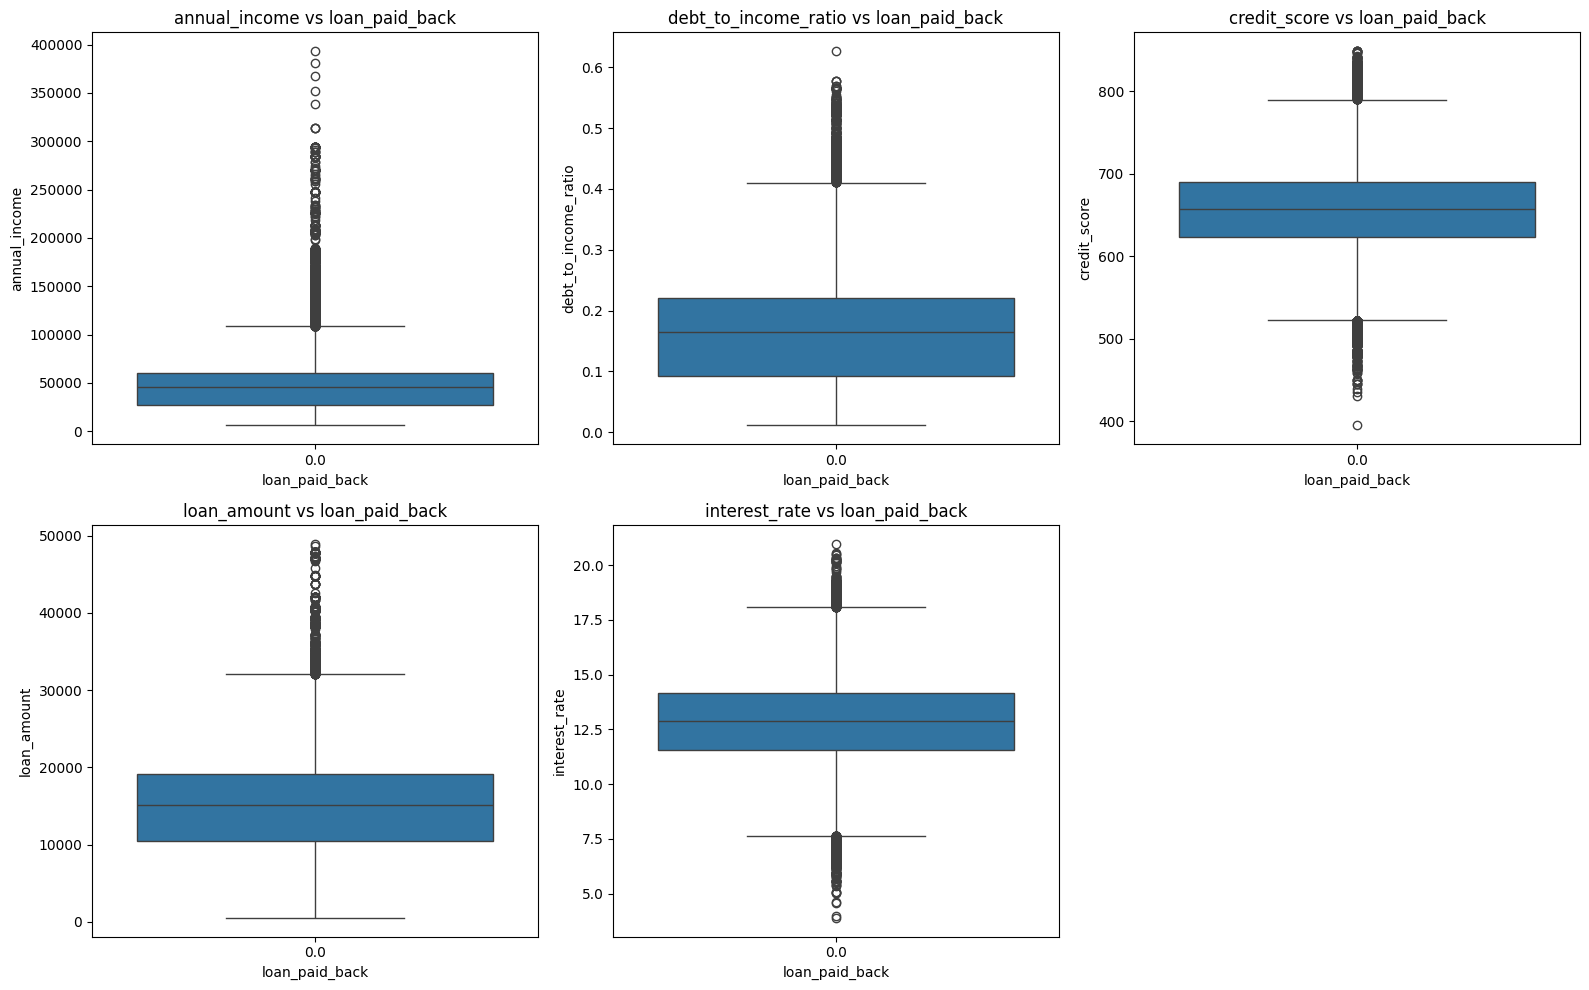

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['annual_income','debt_to_income_ratio','credit_score',
            'loan_amount','interest_rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))  # make space for all
axes = axes.flatten()  # easier indexing

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='loan_paid_back', y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs loan_paid_back")

# Hide unused subplot
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


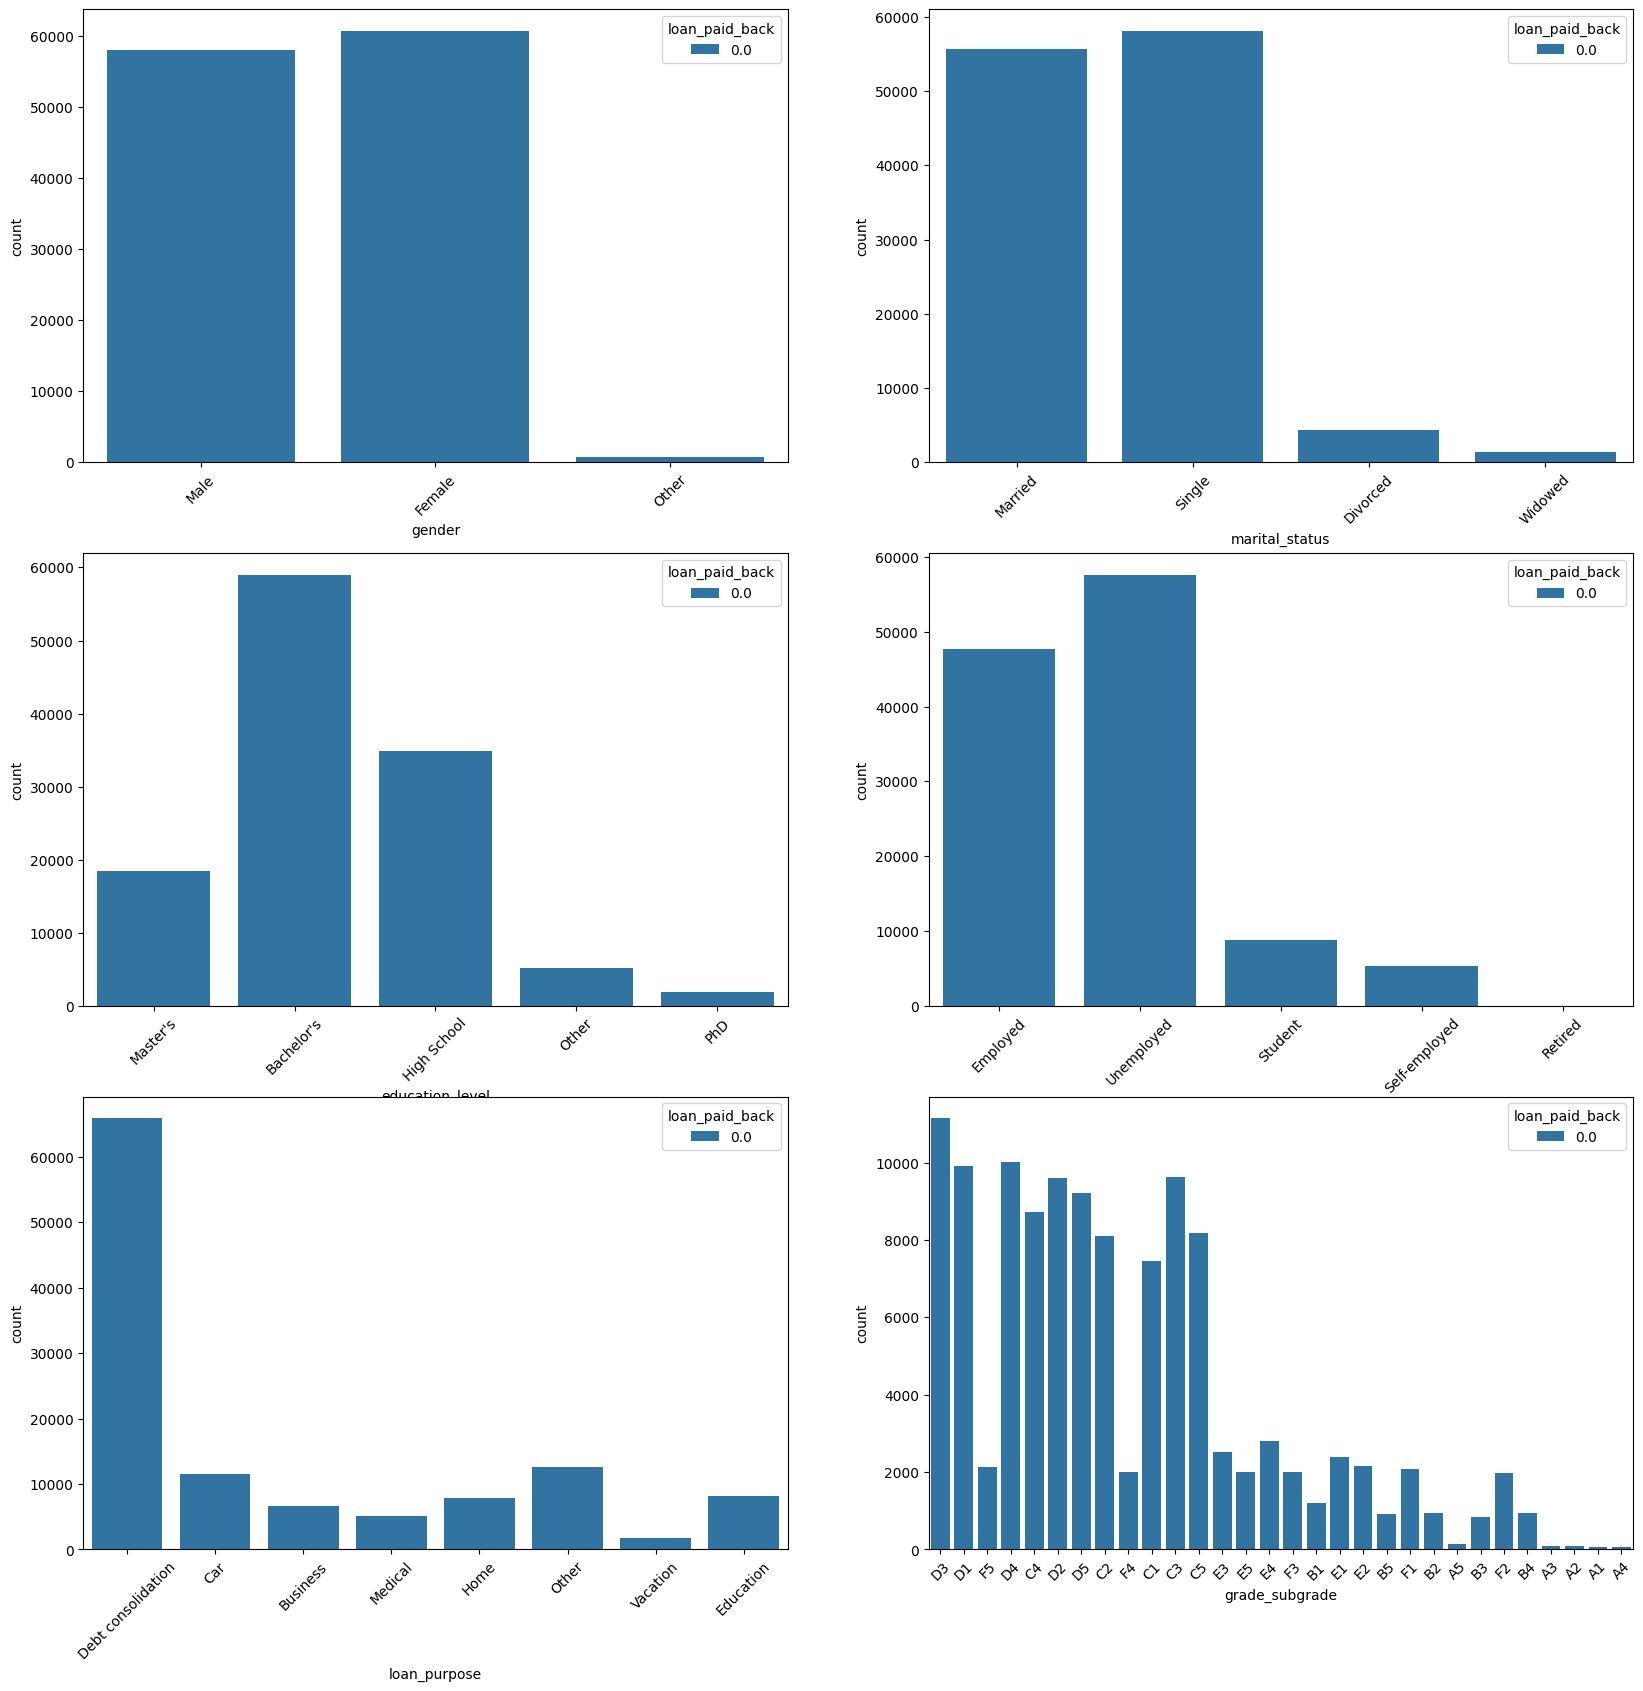

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = ["gender","marital_status","education_level",
                    "employment_status","loan_purpose","grade_subgrade"]

plt.figure(figsize=(20,20))
for i, col in enumerate(categorical_cols,1):
    plt.subplot(3,2,i)
    sns.countplot(data=df, x=col, hue="loan_paid_back")
    plt.xticks(rotation=45)


In [113]:
for col in categorical_cols:
    print("\n====", col, "====")
    print(main.groupby(col)["loan_paid_back"].mean().sort_values())



==== gender ====
gender
Other     0.795333
Male      0.795752
Female    0.801708
Name: loan_paid_back, dtype: float64

==== marital_status ====
marital_status
Widowed     0.789848
Divorced    0.796640
Single      0.798873
Married     0.799144
Name: loan_paid_back, dtype: float64

==== education_level ====
education_level
Bachelor's     0.788892
Master's       0.802346
Other          0.802789
High School    0.809698
PhD            0.830067
Name: loan_paid_back, dtype: float64

==== employment_status ====
employment_status
Unemployed       0.077619
Student          0.263515
Employed         0.894145
Self-employed    0.898457
Retired          0.997204
Name: loan_paid_back, dtype: float64

==== loan_purpose ====
loan_purpose
Education             0.777053
Medical               0.778085
Vacation              0.796071
Debt consolidation    0.796911
Car                   0.800630
Other                 0.802377
Business              0.813104
Home                  0.823224
Name: loan_paid_back

In [116]:
for col in cat_cols:
    print(f"\n==== {col} value counts ====")
    print(main[col].value_counts(dropna=False))
print(main.describe().T)
num_cols = df.select_dtypes(include=['float', 'int']).columns.drop('loan_paid_back')

for col in num_cols:
    print(f"\n==== {col} correlation with target ====")
    print(main[[col, 'loan_paid_back']].corr().iloc[0,1])



==== gender value counts ====
gender
Female    306175
Male      284091
Other       3728
Name: count, dtype: int64

==== marital_status value counts ====
marital_status
Single      288843
Married     277239
Divorced     21312
Widowed       6600
Name: count, dtype: int64

==== education_level value counts ====
education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64

==== employment_status value counts ====
employment_status
Employed         450645
Unemployed        62485
Self-employed     52480
Retired           16453
Student           11931
Name: count, dtype: int64

==== loan_purpose value counts ====
loan_purpose
Debt consolidation    324695
Other                  63874
Car                    58108
Home                   44118
Education              36641
Business               35303
Medical                22806
Vacation                8449
Name: count, dtype: int64

==== grade_subgrade va

In [ ]:
import base64
from io import BytesIO
import matplotlib.pyplot as plt

def show_plot_as_text():
    buf = BytesIO()
    plt.savefig(buf, format='png')
    buf.seek(0)
    encoded = base64.b64encode(buf.read()).decode('utf-8')
    plt.close()
    return encoded

df['credit_score'].hist(bins=50)
plot_text = show_plot_as_text()
print(plot_text)


In [117]:
import pandas as pd

def analyze_bins(df, col, bins=10):
    df['bin'] = pd.qcut(df[col], q=bins, duplicates='drop')
    result = df.groupby('bin')['loan_paid_back'].mean()
    print(f"\n==== {col} repayment by bin ====\n")
    print(result)
    print("\n")
    df.drop(columns=['bin'], inplace=True)

for col in ['annual_income','debt_to_income_ratio','credit_score','loan_amount','interest_rate']:
    analyze_bins(main, col)


C:\Users\16yas\AppData\Local\Temp\ipykernel_48140\3162510236.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('bin')['loan_paid_back'].mean()
C:\Users\16yas\AppData\Local\Temp\ipykernel_48140\3162510236.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('bin')['loan_paid_back'].mean()



==== annual_income repayment by bin ====

bin
(6002.429, 18172.369]     0.797772
(18172.369, 25388.279]    0.797731
(25388.279, 30248.43]     0.782959
(30248.43, 38925.23]      0.805261
(38925.23, 46557.68]      0.788412
(46557.68, 51705.512]     0.797388
(51705.512, 56820.25]     0.799750
(56820.25, 64614.73]      0.800010
(64614.73, 78879.089]     0.805062
(78879.089, 393381.75]    0.813855
Name: loan_paid_back, dtype: float64



==== debt_to_income_ratio repayment by bin ====

bin
(0.009999999999999998, 0.056]    0.924284
(0.056, 0.068]                   0.902937
(0.068, 0.078]                   0.908707
(0.078, 0.088]                   0.859325
(0.088, 0.096]                   0.832122
(0.096, 0.113]                   0.861509
(0.113, 0.142]                   0.835488
(0.142, 0.174]                   0.783894
(0.174, 0.218]                   0.589563
(0.218, 0.627]                   0.485406
Name: loan_paid_back, dtype: float64




C:\Users\16yas\AppData\Local\Temp\ipykernel_48140\3162510236.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('bin')['loan_paid_back'].mean()
C:\Users\16yas\AppData\Local\Temp\ipykernel_48140\3162510236.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('bin')['loan_paid_back'].mean()



==== credit_score repayment by bin ====

bin
(394.999, 607.0]    0.638926
(607.0, 637.0]      0.672203
(637.0, 654.0]      0.713468
(654.0, 670.0]      0.763565
(670.0, 682.0]      0.808779
(682.0, 695.0]      0.823223
(695.0, 712.0]      0.852416
(712.0, 727.0]      0.865657
(727.0, 749.0]      0.915129
(749.0, 849.0]      0.941589
Name: loan_paid_back, dtype: float64



==== loan_amount repayment by bin ====

bin
(500.089, 6031.52]       0.791476
(6031.52, 8994.78]       0.804334
(8994.78, 11518.17]      0.818372
(11518.17, 13261.216]    0.808339
(13261.216, 15000.22]    0.785262
(15000.22, 16454.74]     0.790391
(16454.74, 18074.32]     0.810201
(18074.32, 20709.09]     0.772889
(20709.09, 24782.25]     0.808964
(24782.25, 48959.949]    0.797980
Name: loan_paid_back, dtype: float64



==== interest_rate repayment by bin ====

bin
(3.1990000000000003, 9.8]    0.883394
(9.8, 10.65]                 0.851022
(10.65, 11.29]               0.835963
(11.29, 11.86]               0.826354
(1

C:\Users\16yas\AppData\Local\Temp\ipykernel_48140\3162510236.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('bin')['loan_paid_back'].mean()


In [118]:
import pandas as pd

def interaction_strength(df, x, y):
    df['interaction'] = df[x] * df[y]
    print(f"\n==== Interaction: {x} × {y} correlation with target ==== ")
    print(df['interaction'].corr(df['loan_paid_back']))
    df.drop(columns=['interaction'], inplace=True)

pairs = [
    ('debt_to_income_ratio','interest_rate'),
    ('debt_to_income_ratio','credit_score'),
    ('credit_score','interest_rate'),
    ('annual_income','loan_amount')
]

for x, y in pairs:
    interaction_strength(main, x, y)



==== Interaction: debt_to_income_ratio × interest_rate correlation with target ==== 
-0.35504402323912176

==== Interaction: debt_to_income_ratio × credit_score correlation with target ==== 
-0.2965697879327263

==== Interaction: credit_score × interest_rate correlation with target ==== 
-0.013639100244746417

==== Interaction: annual_income × loan_amount correlation with target ==== 
0.0018043978854308583


In [128]:
(np.log10(main['annual_income']) * np.log10(main['loan_amount']) * main["debt_to_income_ratio"]).corr(main['loan_paid_back'])

np.float64(-0.3305066503382634)

<Axes: xlabel='loan_paid_back', ylabel='None'>

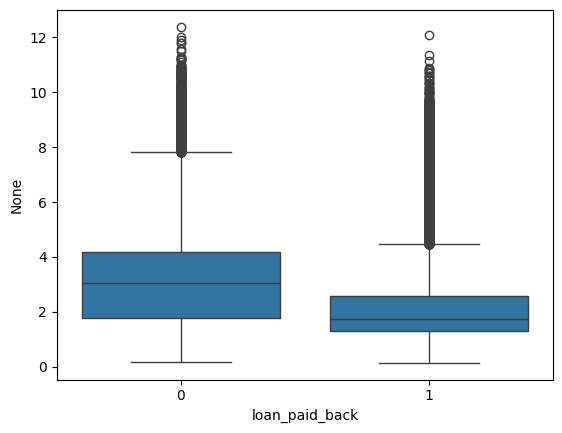

In [129]:
import seaborn as sns
sns.boxplot(x=main['loan_paid_back'], y=np.log10(main['annual_income']) * np.log10(main['loan_amount']) * main["debt_to_income_ratio"])


In [130]:
f1 = np.sqrt(main['annual_income']) * np.sqrt(main['loan_amount']) * main["debt_to_income_ratio"]
f2 = (main['annual_income'] / main['loan_amount']) * main["debt_to_income_ratio"]
f3 = main['loan_amount'] / (main['annual_income'] * main["debt_to_income_ratio"])

print(f1.corr(main['loan_paid_back']))
print(f2.corr(main['loan_paid_back']))
print(f3.corr(main['loan_paid_back']))


-0.2624614860372877
-0.08906135902564141
0.11635506550324494


In [131]:
import numpy as np
import pandas as pd

x = main.copy()
# Create the same variable used in your boxplot
x["combined_metric"] = (
    np.log10(x['annual_income']) *
    np.log10(x['loan_amount']) *
    x["debt_to_income_ratio"]
)

# Group statistics by loan_paid_back
stats = x.groupby("loan_paid_back")["combined_metric"].describe()

print(stats)
print("\nDifference in medians:")
print(stats["50%"])


                   count      mean       std       min       25%       50%  \
loan_paid_back                                                               
0               119500.0  3.157516  1.600848  0.177050  1.768546  3.043899   
1               474494.0  2.071383  1.135749  0.141211  1.311439  1.737931   

                     75%        max  
loan_paid_back                       
0               4.186393  12.384940  
1               2.580995  12.083156  

Difference in medians:
loan_paid_back
0    3.043899
1    1.737931
Name: 50%, dtype: float64


In [138]:
print((x["combined_metric"]).corr(x["loan_paid_back"]))
print((x["combined_metric"]).corr(x["loan_paid_back"]))
print(np.sqrt(x["combined_metric"]**2).corr(x["loan_paid_back"]))


-0.3305066503382634
-0.32466984640170987
-0.3305066503382634


In [139]:
x.groupby(pd.qcut(x["combined_metric"], 10))["loan_paid_back"].mean()

C:\Users\16yas\AppData\Local\Temp\ipykernel_48140\1725714874.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x.groupby(pd.qcut(x["combined_metric"], 10))["loan_paid_back"].mean()


combined_metric
(0.13999999999999999, 1.046]    0.923316
(1.046, 1.277]                  0.908248
(1.277, 1.461]                  0.894156
(1.461, 1.648]                  0.870387
(1.648, 1.84]                   0.841176
(1.84, 2.129]                   0.851546
(2.129, 2.675]                  0.834596
(2.675, 3.306]                  0.767403
(3.306, 4.157]                  0.612569
(4.157, 12.385]                 0.484798
Name: loan_paid_back, dtype: float64

ValueError: could not convert string to float: 'Female'

In [155]:
np.abs(main.corr()['loan_paid_back']).sort_values(ascending=False).head(10)

ValueError: could not convert string to float: 'Female'

In [162]:
np.abs(x[['annual_income', 'debt_to_income_ratio', 'loan_amount', 'interest_rate', 'combined_metric', 'loan_paid_back']].corr()['loan_paid_back']).sort_values(ascending=False).head(10)

loan_paid_back          1.000000
debt_to_income_ratio    0.335680
combined_metric         0.330507
interest_rate           0.131184
annual_income           0.006326
loan_amount             0.003762
Name: loan_paid_back, dtype: float64

In [163]:
for col in main.select_dtypes(include='object').columns:
    print("====", col, "====")
    print(main.groupby(col)['loan_paid_back'].mean())
    print()

==== gender ====
gender
Female    0.801708
Male      0.795752
Other     0.795333
Name: loan_paid_back, dtype: float64

==== marital_status ====
marital_status
Divorced    0.796640
Married     0.799144
Single      0.798873
Widowed     0.789848
Name: loan_paid_back, dtype: float64

==== education_level ====
education_level
Bachelor's     0.788892
High School    0.809698
Master's       0.802346
Other          0.802789
PhD            0.830067
Name: loan_paid_back, dtype: float64

==== employment_status ====
employment_status
Employed         0.894145
Retired          0.997204
Self-employed    0.898457
Student          0.263515
Unemployed       0.077619
Name: loan_paid_back, dtype: float64

==== loan_purpose ====
loan_purpose
Business              0.813104
Car                   0.800630
Debt consolidation    0.796911
Education             0.777053
Home                  0.823224
Medical               0.778085
Other                 0.802377
Vacation              0.796071
Name: loan_paid_back,

In [160]:
x

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,combined_metric
0,0,29367.990234,0.084,736,2528.419922,13.67,Female,Single,High School,Self-employed,Other,C3,1,1.277094
1,1,22108.019531,0.166,636,4593.100098,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0,2.641093
2,2,49566.199219,0.097,694,17005.150391,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1,1.926746
3,3,46858.250000,0.065,533,4682.479980,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1,1.114360
4,4,25496.699219,0.053,665,12184.429688,10.21,Male,Married,High School,Employed,Other,D1,1,0.954214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,4165,23004.259766,0.152,703,20958.369141,10.92,Female,Single,High School,Employed,Business,C3,1,2.865038
593990,4166,35289.429688,0.105,559,3257.239990,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1,1.677395
593991,4167,47112.640625,0.072,675,929.270020,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1,0.998679
593992,4168,76748.437500,0.067,740,16290.400391,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1,1.378564


In [164]:
grade_order = main['grade_subgrade'].sort_values().unique().tolist()
grade_subgrade_map = {grade: i+1 for i, grade in enumerate(grade_order)}
grade_subgrade_map

{'A1': 1,
 'A2': 2,
 'A3': 3,
 'A4': 4,
 'A5': 5,
 'B1': 6,
 'B2': 7,
 'B3': 8,
 'B4': 9,
 'B5': 10,
 'C1': 11,
 'C2': 12,
 'C3': 13,
 'C4': 14,
 'C5': 15,
 'D1': 16,
 'D2': 17,
 'D3': 18,
 'D4': 19,
 'D5': 20,
 'E1': 21,
 'E2': 22,
 'E3': 23,
 'E4': 24,
 'E5': 25,
 'F1': 26,
 'F2': 27,
 'F3': 28,
 'F4': 29,
 'F5': 30}

In [186]:
df = main.copy()
df["grade_num"] = df.grade_subgrade.map(grade_subgrade_map)   # if not done already

tests = {
    "g × loan": df.grade_num * df.loan_amount,
    "g × log10(dti)": df.grade_num * df.debt_to_income_ratio,
    "g × int": df.grade_num * df.interest_rate,
    "g × log10(loan) × dti": df.grade_num * np.log10(df.loan_amount) * df.debt_to_income_ratio,
    "log10(ann_income) × log10(loan) × dti": np.log10(df.annual_income) * np.log10(df.loan_amount) * df.debt_to_income_ratio,
    "log10(loan)": np.log10(df.annual_income),
}

for name, expr in tests.items():
    print(name, expr.corr(df.loan_paid_back))


g × loan -0.12507633755333283
g × log10(dti) -0.01523352170588703
g × int -0.2087112289370676
g × log10(loan) × dti -0.37972834406912304
log10(ann_income) × log10(loan) × dti -0.3305066503382634
log10(loan) 0.008247902280849033


In [179]:
grade_subgrade_map = {grade: i+1 for i, grade in enumerate(grade_order)}

In [181]:
grade_subgrade_map = {
    'A1': 1,
    'A2': 2,
    'A3': 3,
    'A4': 4,
    'A5': 5,
    'B1': 6,
    'B2': 7,
    'B3': 8,
    'B4': 9,
    'B5': 10,
    'C1': 11,
    'C2': 12,
    'C3': 13,
    'C4': 14,
    'C5': 15,
    'D1': 16,
    'D2': 17,
    'D3': 18,
    'D4': 19,
    'D5': 20,
    'E1': 21,
    'E2': 22,
    'E3': 23,
    'E4': 24,
    'E5': 25,
    'F1': 26,
    'F2': 27,
    'F3': 28,
    'F4': 29,
    'F5': 30
}

In [194]:
# For preprocessing function

numeric_cols = [
    'log_income_loan_dti', 'grade_num', 
    'annual_income', 'debt_to_income_ratio',
    'interest_rate', 'credit_score',
    'grade_dti_loan', 'grade_num_dti',
    'loan_amount'
]

category_cols = [
    'gender', 'marital_status',
    'education_level', 'employment_status',
    'loan_purpose', 'grade_subgrade'      
]

def preprocessing_new_findings(data):
    data = data.copy()

    # Map grade_subgrade to numeric
    data['grade_num'] = data.grade_subgrade.map(grade_subgrade_map)
    # data = data.drop(columns="grade_subgrade")
    # Grade DTI interaction.
    data['grade_num_dti'] = data.grade_num * data.debt_to_income_ratio

    data['grade_dti_loan'] =  data.grade_num * data.debt_to_income_ratio * np.log10(data.loan_amount)

    # Create combined metric feature
    data["log_income_loan_dti"] = (
        np.log10(data['annual_income']) *
        np.log10(data['loan_amount']) *
        data["debt_to_income_ratio"]
    )
    data[category_cols] = data[category_cols].astype('category')
    return data

In [188]:
main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int16  
 1   annual_income         593994 non-null  float32
 2   debt_to_income_ratio  593994 non-null  float32
 3   credit_score          593994 non-null  int16  
 4   loan_amount           593994 non-null  float32
 5   interest_rate         593994 non-null  float32
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  int8   
dtypes: float32(4), int16(2), int8(1), object(6)
memory usage: 39.1+ MB


Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'gender', 'marital_status', 'education_level',
       'employment_status', 'loan_purpose', 'grade_subgrade', 'grade_num',
       'grade_num_dti', 'grade_dti_loan', 'log_income_loan_dti'],
      dtype='object')
Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'gender', 'marital_status', 'education_level',
       'employment_status', 'loan_purpose', 'grade_subgrade', 'grade_num',
       'grade_num_dti', 'grade_dti_loan', 'log_income_loan_dti'],
      dtype='object')
--- Fold 1/5 ---

🔹 LightGBM Performance:
ROC-AUC: 0.9230661591727052
              precision    recall  f1-score   support

           0       0.75      0.73      0.74     23900
           1       0.93      0.94      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.84      0.83      0.84    118799
weighted avg       0.90      0.9

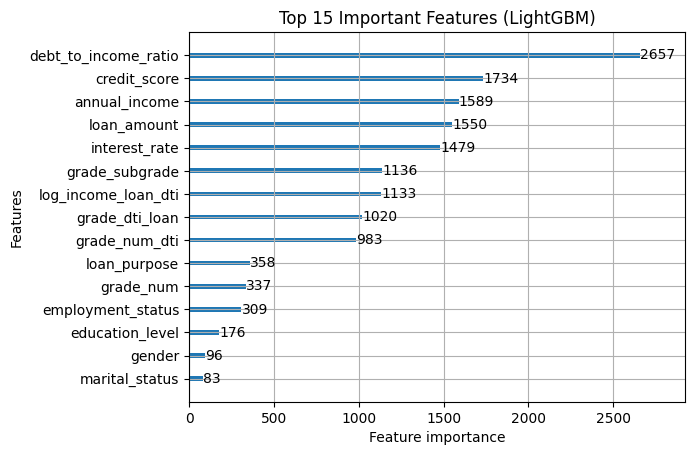

In [205]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

skf = StratifiedKFold(random_state=42, shuffle=True, n_splits=5)

train_org = pd.read_csv(r"../playground-series-s5e11/train_optimized.csv")
test = pd.read_csv(r"../playground-series-s5e11/test.csv")

processed_df = preprocessing_new_findings(data=train_org.copy())
processed_test = preprocessing_new_findings(test)

# 🧩 Step 1: Split data
X = processed_df.drop('loan_paid_back', axis=1)  # replace with your target column
X = X.drop('id', axis=1)  # replace with your target column
y = processed_df['loan_paid_back']

X_res = processed_test.drop('id', axis=1)  # Assuming test set doesn't have target
# X_res[test_cols] = X[test_cols].astype('float64')
X_id = processed_test['id']

print(X_res.columns)
print(X.columns)

oof_preds_lgb = np.zeros(len(X))
# oof_preds_xgb = np.zeros(len(X))
test_preds = np.zeros(len(test))



# X[all_cols] = X[all_cols].astype('float64')
# X[cat_cols] = X[cat_cols].astype('category')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{5} ---')

    X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------------------------------------
    # ⚡ Option 1: LightGBM
    # ----------------------------------------------------------
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=10000,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        reg_lambda=0,
        reg_alpha=0.5,
        subsample=0.8,
        min_child_samples=75,
        colsample_bytree=0.6,
        random_state=42,
        scale_pos_weight=1/2.3,
        # is_unbalance=True,
        n_jobs=-1,
        early_stopping_rounds=150,
        verbose=-1
    )

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc'
    )
    
    y_pred_lgb = lgb_model.predict(X_test)
    y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
    test_preds += lgb_model.predict_proba(X_res, num_iteration=lgb_model.best_iteration_)[:, 1]

    print("\n🔹 LightGBM Performance:")
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lgb))

    oof_preds_lgb[val_idx] = lgb_model.predict_proba(X_test, num_iteration=lgb_model.best_iteration_)[:, 1]
    print(classification_report(y_test, y_pred_lgb))
    print(confusion_matrix(y_test, (y_pred_lgb > 0.5).astype(int)))


print(f'====================')
print("OOF AUC: LGBM:", roc_auc_score(y, oof_preds_lgb))
print(f'Overall OOF AUC rounded to 4: {roc_auc_score(y, oof_preds_lgb):.4f}')
# print("OOF AUC: XGB", roc_auc_score(y, oof_preds_xgb))
print(f'====================')


# ----------------------------------------------------------
# 🔍 Feature Importance (example for LightGBM)
# ----------------------------------------------------------
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, max_num_features=20)
plt.title("Top 15 Important Features (LightGBM)")
plt.show()

# xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain')


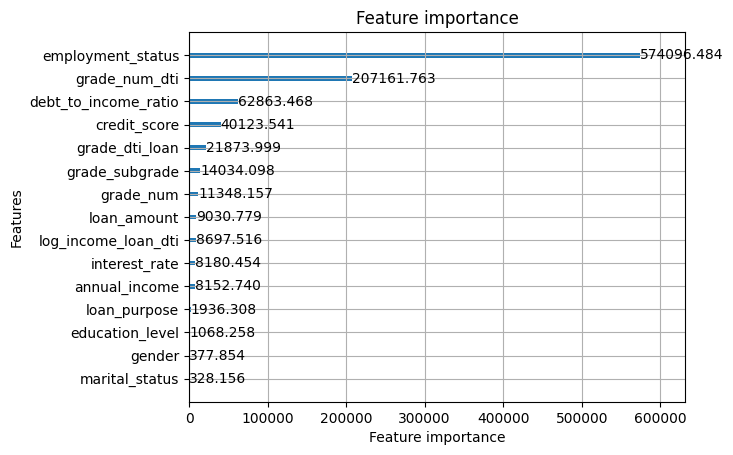

In [200]:
lgb.plot_importance(lgb_model, importance_type='gain')
plt.show()

In [206]:
pd.DataFrame({
    'id': X_id,
    'loan_paid_back': test_preds
}).to_csv(r'../submission003.csv', index=False)

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'grade_num', 'grade_num_dti', 'grade_dti_loan',
       'gender_Male', 'gender_Other', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed',
       'education_level_High School', 'education_level_Master's',
       'education_level_Other', 'education_level_PhD',
       'employment_status_Retired', 'employment_status_Self-employed',
       'employment_status_Student', 'employment_status_Unemployed',
       'loan_purpose_Car', 'loan_purpose_Debt consolidation',
       'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Medical',
       'loan_purpose_Other', 'loan_purpose_Vacation', 'grade_subgrade_A2',
       'grade_subgrade_A3', 'grade_subgrade_A4', 'grade_subgrade_A5',
       'grade_subgrade_B1', 'grade_subgrade_B2', 'grade_subgrade_B3',
       'grade_subgrade_B4', 'grade_subgrade_B5', 'grade_subgrade_C1',
       'grade_subgrade_C2', 'grade_subgrad

ValueError: train and valid dataset categorical_feature do not match.

488

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'grade_num', 'grade_num_dti', 'grade_dti_loan',
       'gender_Male', 'gender_Other', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed',
       'education_level_High School', 'education_level_Master's',
       'education_level_Other', 'education_level_PhD',
       'employment_status_Retired', 'employment_status_Self-employed',
       'employment_status_Student', 'employment_status_Unemployed',
       'loan_purpose_Car', 'loan_purpose_Debt consolidation',
       'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Medical',
       'loan_purpose_Other', 'loan_purpose_Vacation', 'grade_subgrade_A2',
       'grade_subgrade_A3', 'grade_subgrade_A4', 'grade_subgrade_A5',
       'grade_subgrade_B1', 'grade_subgrade_B2', 'grade_subgrade_B3',
       'grade_subgrade_B4', 'grade_subgrade_B5', 'grade_subgrade_C1',
       'grade_subgrade_C2', 'grade_subgrad

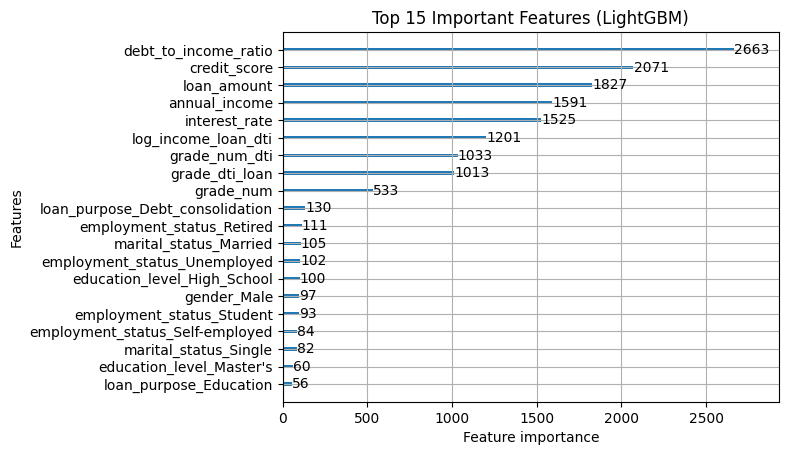

In [218]:
# With Encodings Setup 
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix


# For preprocessing function

numeric_cols = [
    'log_income_loan_dti', 'grade_num', 
    'annual_income', 'debt_to_income_ratio',
    'interest_rate', 'credit_score',
    'grade_dti_loan', 'grade_num_dti',
    'loan_amount'
]

category_cols = [
    'gender', 'marital_status',
    'education_level', 'employment_status',
    'loan_purpose', 'grade_subgrade'      
]

def preprocessing_new_findings(data):
    data = data.copy()

    # Map grade_subgrade to numeric
    data['grade_num'] = data.grade_subgrade.map(grade_subgrade_map)
    # data = data.drop(columns="grade_subgrade")
    # Grade DTI interaction.
    data['grade_num_dti'] = data.grade_num * data.debt_to_income_ratio

    data['grade_dti_loan'] =  data.grade_num * data.debt_to_income_ratio * np.log10(data.loan_amount)

    data = pd.get_dummies(data=data, columns=category_cols, drop_first=True)

    # Create combined metric feature
    data["log_income_loan_dti"] = (
        np.log10(data['annual_income']) *
        np.log10(data['loan_amount']) *
        data["debt_to_income_ratio"]
    )
    # data[category_cols] = data[category_cols].astype('category')
    return data


import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

skf = StratifiedKFold(random_state=42, shuffle=True, n_splits=5)

train_org = pd.read_csv(r"../playground-series-s5e11/train_optimized.csv")
test = pd.read_csv(r"../playground-series-s5e11/test.csv")

processed_df = preprocessing_new_findings(data=train_org.copy())
processed_test = preprocessing_new_findings(test)

# 🧩 Step 1: Split data
X = processed_df.drop('loan_paid_back', axis=1)  # replace with your target column
X = X.drop('id', axis=1)  # replace with your target column
y = processed_df['loan_paid_back']

X_res = processed_test.drop('id', axis=1)  # Assuming test set doesn't have target
# X_res[test_cols] = X[test_cols].astype('float64')
X_id = processed_test['id']

print(X_res.columns)
print(X.columns)

oof_preds_lgb = np.zeros(len(X))
# oof_preds_xgb = np.zeros(len(X))
test_preds = np.zeros(len(test))



# X[all_cols] = X[all_cols].astype('float64')
# X[cat_cols] = X[cat_cols].astype('category')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{5} ---')

    X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------------------------------------
    # ⚡ Option 1: LightGBM
    # ----------------------------------------------------------
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=10000,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        reg_lambda=0,
        reg_alpha=0.5,
        subsample=0.8,
        min_child_samples=75,
        colsample_bytree=0.6,
        random_state=42,
        scale_pos_weight=1/2.3,
        # is_unbalance=True,
        n_jobs=-1,
        early_stopping_rounds=150,
        verbose=-1
    )

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc'
    )
    
    y_pred_lgb = lgb_model.predict(X_test)
    y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
    test_preds += lgb_model.predict_proba(X_res, num_iteration=lgb_model.best_iteration_)[:, 1] / 5

    print("\n🔹 LightGBM Performance:")
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lgb))

    oof_preds_lgb[val_idx] = lgb_model.predict_proba(X_test, num_iteration=lgb_model.best_iteration_)[:, 1]
    print(classification_report(y_test, y_pred_lgb))
    print(confusion_matrix(y_test, (y_pred_lgb > 0.5).astype(int)))


print(f'====================')
print("OOF AUC: LGBM:", roc_auc_score(y, oof_preds_lgb))
print(f'Overall OOF AUC rounded to 4: {roc_auc_score(y, oof_preds_lgb):.4f}')
# print("OOF AUC: XGB", roc_auc_score(y, oof_preds_xgb))
print(f'====================')


# ----------------------------------------------------------
# 🔍 Feature Importance (example for LightGBM)
# ----------------------------------------------------------
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, max_num_features=20)
plt.title("Top 15 Important Features (LightGBM)")
plt.show()

# xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain')


In [219]:
pd.DataFrame({
    'id': X_id,
    'loan_paid_back': test_preds
}).to_csv(r'../submission006.csv', index=False)

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'grade_num', 'grade_num_dti', 'grade_dti_loan',
       'gender_Male', 'gender_Other', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed',
       'education_level_High School', 'education_level_Master's',
       'education_level_Other', 'education_level_PhD',
       'employment_status_Retired', 'employment_status_Self-employed',
       'employment_status_Student', 'employment_status_Unemployed',
       'loan_purpose_Car', 'loan_purpose_Debt consolidation',
       'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Medical',
       'loan_purpose_Other', 'loan_purpose_Vacation', 'grade_subgrade_A2',
       'grade_subgrade_A3', 'grade_subgrade_A4', 'grade_subgrade_A5',
       'grade_subgrade_B1', 'grade_subgrade_B2', 'grade_subgrade_B3',
       'grade_subgrade_B4', 'grade_subgrade_B5', 'grade_subgrade_C1',
       'grade_subgrade_C2', 'grade_subgrad

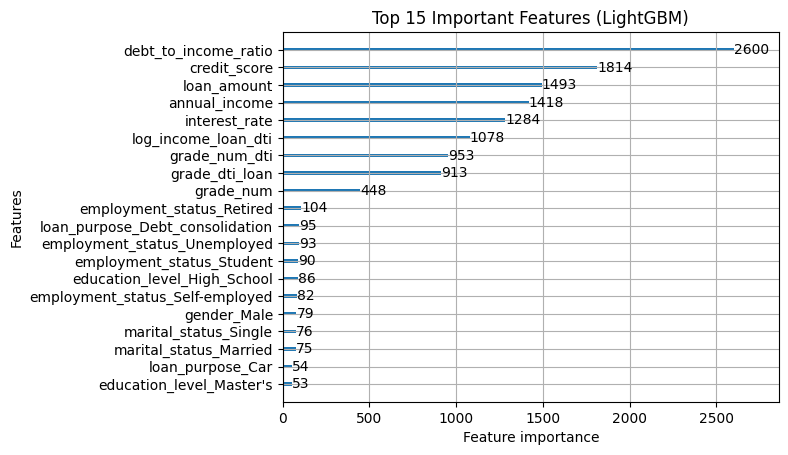

In [220]:
# With Encodings Setup scale pos 1/2.5
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix


# For preprocessing function

numeric_cols = [
    'log_income_loan_dti', 'grade_num', 
    'annual_income', 'debt_to_income_ratio',
    'interest_rate', 'credit_score',
    'grade_dti_loan', 'grade_num_dti',
    'loan_amount'
]

category_cols = [
    'gender', 'marital_status',
    'education_level', 'employment_status',
    'loan_purpose', 'grade_subgrade'      
]

def preprocessing_new_findings(data):
    data = data.copy()

    # Map grade_subgrade to numeric
    data['grade_num'] = data.grade_subgrade.map(grade_subgrade_map)
    # data = data.drop(columns="grade_subgrade")
    # Grade DTI interaction.
    data['grade_num_dti'] = data.grade_num * data.debt_to_income_ratio

    data['grade_dti_loan'] =  data.grade_num * data.debt_to_income_ratio * np.log10(data.loan_amount)

    data = pd.get_dummies(data=data, columns=category_cols, drop_first=True)

    # Create combined metric feature
    data["log_income_loan_dti"] = (
        np.log10(data['annual_income']) *
        np.log10(data['loan_amount']) *
        data["debt_to_income_ratio"]
    )
    # data[category_cols] = data[category_cols].astype('category')
    return data


import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

skf = StratifiedKFold(random_state=42, shuffle=True, n_splits=5)

train_org = pd.read_csv(r"../playground-series-s5e11/train_optimized.csv")
test = pd.read_csv(r"../playground-series-s5e11/test.csv")

processed_df = preprocessing_new_findings(data=train_org.copy())
processed_test = preprocessing_new_findings(test)

# 🧩 Step 1: Split data
X = processed_df.drop('loan_paid_back', axis=1)  # replace with your target column
X = X.drop('id', axis=1)  # replace with your target column
y = processed_df['loan_paid_back']

X_res = processed_test.drop('id', axis=1)  # Assuming test set doesn't have target
# X_res[test_cols] = X[test_cols].astype('float64')
X_id = processed_test['id']

print(X_res.columns)
print(X.columns)

oof_preds_lgb = np.zeros(len(X))
# oof_preds_xgb = np.zeros(len(X))
test_preds = np.zeros(len(test))



# X[all_cols] = X[all_cols].astype('float64')
# X[cat_cols] = X[cat_cols].astype('category')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{5} ---')

    X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------------------------------------
    # ⚡ Option 1: LightGBM
    # ----------------------------------------------------------
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=10000,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        reg_lambda=0,
        reg_alpha=0.5,
        subsample=0.8,
        min_child_samples=75,
        colsample_bytree=0.6,
        random_state=42,
        scale_pos_weight=1/2.5,
        # is_unbalance=True,
        n_jobs=-1,
        early_stopping_rounds=150,
        verbose=-1
    )

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc'
    )
    
    y_pred_lgb = lgb_model.predict(X_test)
    y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
    test_preds += lgb_model.predict_proba(X_res, num_iteration=lgb_model.best_iteration_)[:, 1] / 5

    print("\n🔹 LightGBM Performance:")
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lgb))

    oof_preds_lgb[val_idx] = lgb_model.predict_proba(X_test, num_iteration=lgb_model.best_iteration_)[:, 1]
    print(classification_report(y_test, y_pred_lgb))
    print(confusion_matrix(y_test, (y_pred_lgb > 0.5).astype(int)))


print(f'====================')
print("OOF AUC: LGBM:", roc_auc_score(y, oof_preds_lgb))
print(f'Overall OOF AUC rounded to 4: {roc_auc_score(y, oof_preds_lgb):.4f}')
# print("OOF AUC: XGB", roc_auc_score(y, oof_preds_xgb))
print(f'====================')


# ----------------------------------------------------------
# 🔍 Feature Importance (example for LightGBM)
# ----------------------------------------------------------
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, max_num_features=20)
plt.title("Top 15 Important Features (LightGBM)")
plt.show()

# xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain')


In [221]:
pd.DataFrame({
    'id': X_id,
    'loan_paid_back': test_preds
}).to_csv(r'../submission007.csv', index=False)

In [ ]:
# OHE With Encodings Setup final model

# With Encodings Setup 
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix


# For preprocessing function

numeric_cols = [
    'log_income_loan_dti', 'grade_num', 
    'annual_income', 'debt_to_income_ratio',
    'interest_rate', 'credit_score',
    'grade_dti_loan', 'grade_num_dti',
    'loan_amount'
]

category_cols = [
    'gender', 'marital_status',
    'education_level', 'employment_status',
    'loan_purpose', 'grade_subgrade'      
]

def preprocessing_new_findings(data):
    data = data.copy()

    # Map grade_subgrade to numeric
    data['grade_num'] = data.grade_subgrade.map(grade_subgrade_map)
    # data = data.drop(columns="grade_subgrade")
    # Grade DTI interaction.
    data['grade_num_dti'] = data.grade_num * data.debt_to_income_ratio

    data['grade_dti_loan'] =  data.grade_num * data.debt_to_income_ratio * np.log10(data.loan_amount)

    data = pd.get_dummies(data=data, columns=category_cols, drop_first=True)

    # Create combined metric feature
    data["log_income_loan_dti"] = (
        np.log10(data['annual_income']) *
        np.log10(data['loan_amount']) *
        data["debt_to_income_ratio"]
    )
    # data[category_cols] = data[category_cols].astype('category')
    return data


import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

skf = StratifiedKFold(random_state=42, shuffle=True, n_splits=5)

train_org = pd.read_csv(r"../playground-series-s5e11/train_optimized.csv")
test = pd.read_csv(r"../playground-series-s5e11/test.csv")

processed_df = preprocessing_new_findings(data=train_org.copy())
processed_test = preprocessing_new_findings(test)

# 🧩 Step 1: Split data
X = processed_df.drop('loan_paid_back', axis=1)  # replace with your target column
X = X.drop('id', axis=1)  # replace with your target column
y = processed_df['loan_paid_back']

X_res = processed_test.drop('id', axis=1)  # Assuming test set doesn't have target
# X_res[test_cols] = X[test_cols].astype('float64')
X_id = processed_test['id']

print(X_res.columns)
print(X.columns)

oof_preds_lgb = np.zeros(len(X))
# oof_preds_xgb = np.zeros(len(X))
test_preds = np.zeros(len(test))

# ----------------------------------------------------------
# ⚡ Option 1: LightGBM
# ----------------------------------------------------------
lgb_model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=10000,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    reg_lambda=0,
    reg_alpha=0.5,
    subsample=0.8,
    min_child_samples=75,
    colsample_bytree=0.6,
    random_state=42,
    scale_pos_weight=1/2.3,
    # is_unbalance=True,
    n_jobs=-1,
    # early_stopping_rounds=150,
    verbose=-1
)

lgb_model.fit(
    X, y,
    eval_metric='auc'
)

y_pred_lgb = lgb_model.predict(X_test)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
test_preds += lgb_model.predict_proba(X_res, num_iteration=lgb_model.best_iteration_)[:, 1] / 5

print("\n🔹 LightGBM Performance:")
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lgb))

oof_preds_lgb[val_idx] = lgb_model.predict_proba(X_test, num_iteration=lgb_model.best_iteration_)[:, 1]
print(classification_report(y_test, y_pred_lgb))
print(confusion_matrix(y_test, (y_pred_lgb > 0.5).astype(int)))


print(f'====================')
print("OOF AUC: LGBM:", roc_auc_score(y, oof_preds_lgb))
print(f'Overall OOF AUC rounded to 4: {roc_auc_score(y, oof_preds_lgb):.4f}')
# print("OOF AUC: XGB", roc_auc_score(y, oof_preds_xgb))
print(f'====================')


# ----------------------------------------------------------
# 🔍 Feature Importance (example for LightGBM)
# ----------------------------------------------------------
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, max_num_features=20)
plt.title("Top 15 Important Features (LightGBM)")
plt.show()

# xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain')
# This yieldedl best of score for now

In [226]:
1/2.3

0.4347826086956522

In [ ]:
# Searching for best params
import optuna
from optuna.samplers import TPESampler

def objective(trial):

    # 🔍 Search space
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int("n_estimators", 2000, 12000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.20, log=True),

        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", -1, 16),

        "min_child_samples": trial.suggest_int("min_child_samples", 10, 200),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 3.0),

        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 3.0),

        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1
    }

    # 5-fold CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    oof_preds = np.zeros(len(y))
    
    for train_idx, valid_idx in skf.split(X, y):

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = lgb.LGBMClassifier(**params)
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="auc",
            callbacks=[
                lgb.early_stopping(150, verbose=False)
            ]
        )

        oof_preds[valid_idx] = model.predict_proba(X_valid)[:, 1]

    auc = roc_auc_score(y, oof_preds)
    return auc


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42)
)

study.optimize(objective, n_trials=50, show_progress_bar=True)



[I 2025-11-16 22:50:08,793] A new study created in memory with name: no-name-2fed5455-a285-41a2-ae59-4230dd5f0a97
Best trial: 0. Best value: 0.922187:   2%|▏         | 1/50 [00:52<43:04, 52.74s/it]

[I 2025-11-16 22:51:01,594] Trial 0 finished with value: 0.9221874323447978 and parameters: {'n_estimators': 5745, 'learning_rate': 0.1667521176194013, 'num_leaves': 192, 'max_depth': 9, 'min_child_samples': 39, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.4348501673009197, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 1.8033450352296265, 'scale_pos_weight': 2.2701814444901136}. Best is trial 0 with value: 0.9221874323447978.


Best trial: 1. Best value: 0.923694:   4%|▍         | 2/50 [03:14<1:24:13, 105.29s/it]

[I 2025-11-16 22:53:23,663] Trial 1 finished with value: 0.9236937902561624 and parameters: {'n_estimators': 2205, 'learning_rate': 0.17898794163735265, 'num_leaves': 216, 'max_depth': 2, 'min_child_samples': 44, 'subsample': 0.5917022549267169, 'colsample_bytree': 0.5825453457757226, 'reg_alpha': 1.0495128632644757, 'reg_lambda': 1.2958350559263474, 'scale_pos_weight': 1.2280728504951048}. Best is trial 1 with value: 0.9236937902561624.


In [227]:
import os
os.cpu_count()

16